# EDA: Sleep Disorder · Menopause · Liver · Coronary Heart

**Goal:** Identify top ~20 questionnaire-askable (non-lab) features correlated with each disease.  
Insights will inform ML model strategy and the design of an assessment questionnaire.

**Feature philosophy:** Only features a person can realistically self-report — symptoms, lifestyle,  
demographics, physical self-measurements (height, weight, BP), activity, diet, sleep, work schedule.  
Medical record items (drug names, ICD codes, age-of-diagnosis) are excluded.

| Disease | Definition |
|---------|------------|
| `sleep_disorder` | SLQ040 ∈ {2,3} OR SLQ050 == 1 |
| `menopause` | RHQ305==1 OR RHD043==7 OR (RHQ031==2 AND age>40) |
| `liver` | Any of MCQ510a–f flagged |
| `coronary_heart` | MCQ160c == 1 |

**Section 9** analyses the 'mystery fatigue' group: DPQ040 score 2–3 with zero of the 15 diseases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pointbiserialr, mannwhitneyu, chi2_contingency, kruskal
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

DISEASES   = ['sleep_disorder', 'menopause', 'liver', 'coronary_heart']
COLORS     = {'sleep_disorder': '#4e79a7', 'menopause': '#f28e2b',
              'liver': '#e15759', 'coronary_heart': '#76b7b2'}
TARGET_DPQ = 'dpq040___feeling_tired_or_having_little_energy'
ALL_15     = ['anemia','diabetes','thyroid','sleep_disorder','kidney',
              'hepatitis_bc','liver','heart_failure','coronary_heart',
              'emphysema_lungs','high_blood_pressure','high_cholesterol',
              'menopause','overweight','alcohol']

df = pd.read_csv('../data/processed/nhanes_merged_adults_final.csv', low_memory=False)
df[TARGET_DPQ] = df[TARGET_DPQ].replace({7: np.nan, 9: np.nan})
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} cols')

Loaded: 7,437 rows × 868 cols


---
## 1. Build the Assessable Feature Pool

In [2]:
# ── Step 1: Remove lab columns ───────────────────────────────────────────────
LAB_PATTERNED = [c for c in df.columns
                 if '_' in c and c.split('_')[0].isupper() and len(c.split('_')[0]) >= 4]

NAMED_LABS = [
    'fasting_glucose_mg_dl','insulin_uU_ml','total_cholesterol_mg_dl',
    'hdl_cholesterol_mg_dl','triglycerides_mg_dl','ferritin_ng_ml',
    'serum_iron_ug_dl','tibc_ug_dl','transferrin_saturation_pct',
    'transferrin_receptor_mg_l','uacr_mg_g','serum_creatinine_mg_dl',
    'bun_mg_dl','alt_u_l','ast_u_l','ggt_u_l','alp_u_l',
    'total_bilirubin_mg_dl','serum_albumin_g_dl',
    'liver_cap_dbm','liver_stiffness_kpa','liver_exam_status',
    'liver_valid_measures','liver_stiffness_iqr_ratio',
    'fasting_hours_part','fasting_minutes_part','LBXIN','LBDINSI','LBDINLC'
]
NAMED_LABS = [c for c in NAMED_LABS if c in df.columns]

# ── Step 2: Remove infrastructure, medication, ICD, medical-record columns ──
DROP_ALWAYS = [
    # Survey metadata
    'SEQN','SEQN.1','mec_exam_weight','interview_weight',
    'survey_psu','survey_stratum',
    'nan_count','nan_group','cluster',
    'fatigue_ordinal','fatigue_binary_lenient','fatigue_binary_strict',

    # Prescription / medication — not assessable, number-of-meds not disease signal
    *[f'medication_{i}' for i in range(1, 23)],
    'med_count',
    'rxduse___taken_prescription_medicine,_past_month',
    'rxddrug___generic_drug_name',
    'rxddrgid___generic_drug_code',
    'rxqseen___medicine_container_seen_by_interviewer',
    'rxddays___number_of_days_taken_medicine',
    'rxdcount___number_of_prescription_medicines_taken',

    # ICD-10 codes
    'rxdrsc1___icd_10_cm_code_1','rxdrsc2___icd_10_cm_code_2',
    'rxdrsc3___icd_10_cm_code_3','rxdrsd1___icd_10_cm_code_1_description',
    'rxdrsd2___icd_10_cm_code_2_description','rxdrsd3___icd_10_cm_code_3_description',

    # Age-of-diagnosis columns (medical record data, not self-report)
    'mcd180b___age_when_told_you_had_chf',
    'mcd180c___age_when_told_you_had_chd',
    'mcd180d___age_when_told_you_had_angina',
    'mcd180e___age_when_told_you_had_heart_attack',
    'mcd180f___age_when_told_you_had_a_stroke',
    'mcd180l___age_when_told_you_had_liver_condition',
    'mcd180m___age_when_told_you_had_thyroid_problem',

    # Cancer sub-type details (clinical specificity not needed for assessment)
    'mcq230a___what_kind_of_cancer_first_mention',
    'mcq230b___what_kind_of_cancer_second_mention',
    'mcq230c___what_kind_of_cancer_third_mention',

    # Clinical follow-up / procedure details
    'cdq006___how_soon_is_the_pain_relieved',   # clinical outcome, not symptom
    'did060___how_long_taking_insulin',          # medical management detail
    'diq060u___unit_of_measure_(month/year)',
    'diq260u___unit_of_measure_(day/week/month/year)',
    'diq350u___unit_of_measure_(day/week/month/year)',
    'osq230___any_metal_objects_inside_your_body?', # MRI safety, not lifestyle
    'smaquex2___questionnaire_mode_flag',            # survey method flag

    # Duplicate physical measures (already have metric bmi / weight_kg / height_cm)
    'whd010___current_self_reported_height_(inches)',
    'whd020___current_self_reported_weight_(pounds)',

    # Historical weight granularity — too specific for quick assessment
    'whd050___self_reported_weight___1_yr_ago_(pounds)',
    'whd110___self_reported_weight_10_yrs_ago_(pounds)',
    'whd120___self_reported_weight_age_25_(pounds)',
    'whd130___self_reported_height___age_25_(inches)',
    'whd140___self_reported_greatest_weight_(pounds)',
    'whq150___age_when_heaviest_weight',
    'whq225___times_lost_10_lbs_or_more_to_lose_weight',

    # Work absence reason — not a disease distinguisher
    'ocd383___main_reason_did_not_work_last_week',

    # Age/range at first menstrual period — redundant with age_years
    'rhq020___age_range_at_first_menstrual_period',
    'rhq070___age_range_at_last_menstrual_period',
    'mcq025___age_when_first_had_asthma',        # medical record
    'mcq151___age_in_years_at_first_menstrual_period',
    'did040___age_when_first_told_you_had_diabetes',
    'smd030___age_started_smoking_cigarettes_regularly',
    'smd630___age_first_smoked_whole_cigarette',
    'rhd190___age_at_last_live_birth',
    'rhd180___age_at_first_live_birth',
]
DROP_ALWAYS = [c for c in DROP_ALWAYS if c in df.columns]

ALL_EXCLUDED = set(LAB_PATTERNED + NAMED_LABS + DROP_ALWAYS)

POOL = [c for c in df.columns
        if c not in ALL_EXCLUDED and c not in ALL_15]

print(f'Assessable feature pool: {len(POOL)} columns')
print(f'  Removed: {len(LAB_PATTERNED)} patterned labs, {len(NAMED_LABS)} named labs,'
      f' {len(DROP_ALWAYS)} administrative/medical-record cols')

Assessable feature pool: 257 columns
  Removed: 484 patterned labs, 29 named labs, 83 administrative/medical-record cols


In [3]:
# ── Per-disease exclusions: source questions + semantic equivalents ──────────
EXCLUDE = {
    'sleep_disorder': [
        'slq040___how_often_do_you_snort_or_stop_breathing',   # source
        'slq050___ever_told_doctor_had_trouble_sleeping?',     # source
        'slq030___how_often_do_you_snore?',                    # same domain
        'sld012___sleep_hours___weekdays_or_workdays',
        'sld013___sleep_hours___weekends',
        'slq300___usual_sleep_time_on_weekdays_or_workdays',
        'slq310___usual_wake_time_on_weekdays_or_workdays',
        'slq320___usual_sleep_time_on_weekends',
        'slq330___usual_wake_time_on_weekends',
    ],
    'menopause': [
        'rhq305___had_both_ovaries_removed?',
        'rhd043___reason_not_having_regular_periods',
        'rhq031___had_regular_periods_in_past_12_months',
        'rhq060___age_at_last_menstrual_period',
        'mcq149___menstrual_periods_started_yet?',
        'rhq540___ever_use_female_hormones?',
        'rhq542a___hormone_pills_used',
        'rhq542b___hormone_patches_used',
        'rhq542c___hormone_cream/suppository/injection_used',
        'rhq554___use_hormone_pills_w/estrogen_only',
        'rhq570___used_estrogen/progestin_combo_pills',
        'rhd280___had_a_hysterectomy?',
        'rhq332___age_when_both_ovaries_removed',
        'rhd143___are_you_pregnant_now?',
        'pregnancy_status',
    ],
    'liver': [
        'mcq510a___liver_condition_fatty_liver',
        'mcq510b___liver_condition_non_alcoholic_fatty_liver',
        'mcq510c___liver_condition_alcoholic_liver_disease',
        'mcq510d___liver_condition_hepatitis',
        'mcq510e___liver_condition_autoimmune',
        'mcq510f___liver_condition_other',
        'mcq160l___ever_told_you_had_any_liver_condition',
        'mcq170l___still_have_liver_condition',
        'mcq500___ever_told_you_had_any_liver_condition',
        'heq010___ever_told_you_have_hepatitis_b?',
        'heq020___ever_prescribed_meds_treat_hepatitis_b?',
        'heq030___ever_told_you_have_hepatitis_c?',
        'heq040___ever_prescribed_meds_treat_hepatitis_c?',
    ],
    'coronary_heart': [
        'mcq160c___ever_told_you_had_coronary_heart_disease',
        'mcq160d___ever_told_you_had_angina',
        'mcq160e___ever_told_you_had_heart_attack',
        'mcq160b___ever_told_you_had_congestive_heart_failure',
        'mcq160f___ever_told_you_had_stroke',
        'mcq300a___close_relative_had_heart_attack',
    ],
}

for disease, excl in EXCLUDE.items():
    present = [c for c in excl if c in df.columns]
    print(f'{disease:<20}: {len(present)} source/equivalent cols excluded')

sleep_disorder      : 9 source/equivalent cols excluded
menopause           : 15 source/equivalent cols excluded
liver               : 13 source/equivalent cols excluded
coronary_heart      : 6 source/equivalent cols excluded


---
## 2. Disease Prevalence

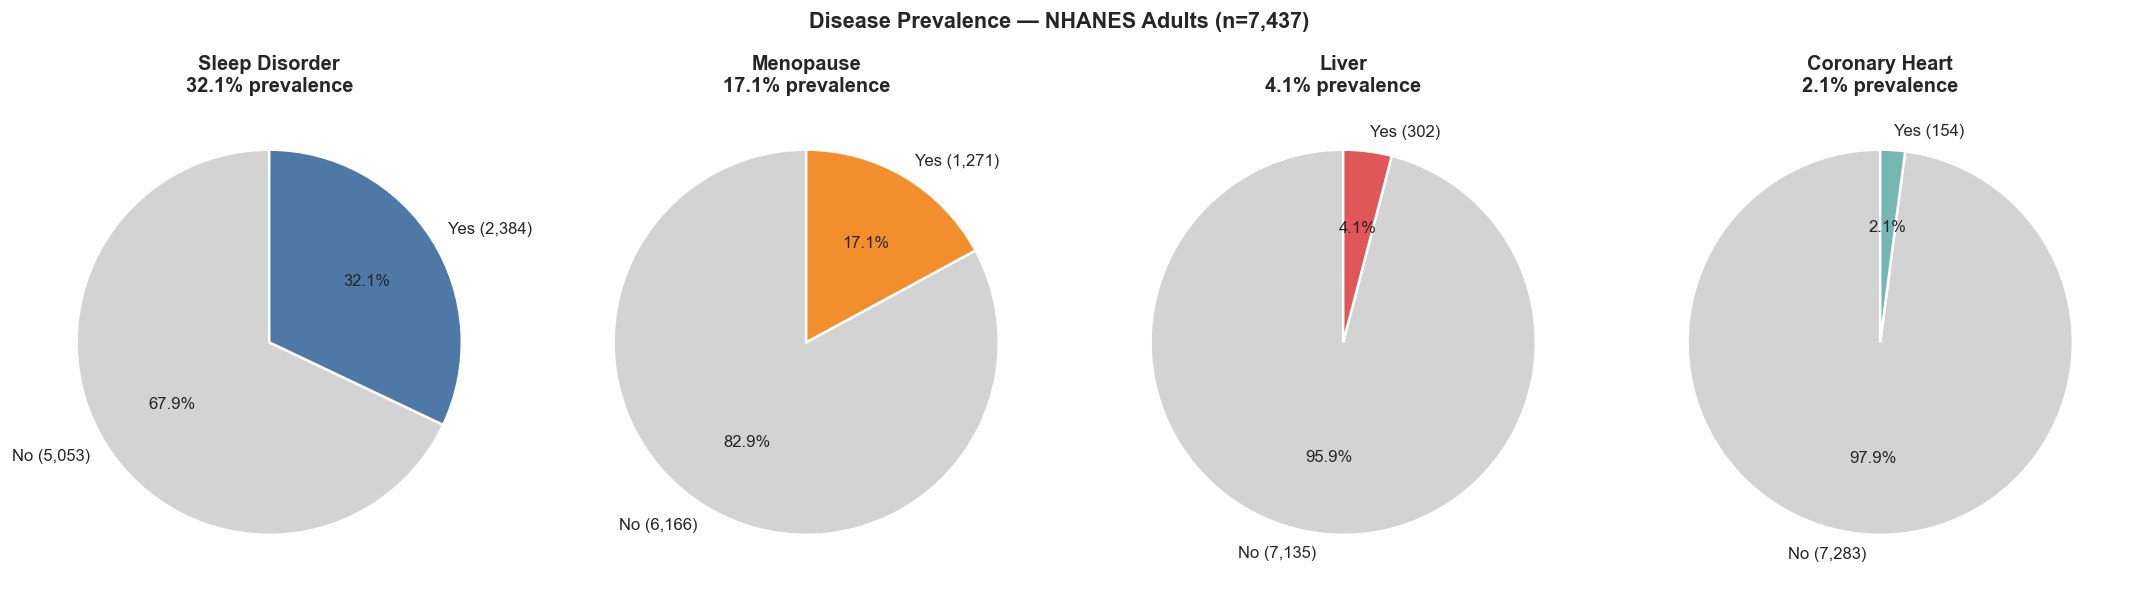

Class balance (0:1 ratio):
  sleep_disorder         pos=2384  neg=5053  ratio=2.1:1
  menopause              pos=1271  neg=6166  ratio=4.9:1
  liver                  pos= 302  neg=7135  ratio=23.6:1
  coronary_heart         pos= 154  neg=7283  ratio=47.3:1


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, disease in zip(axes, DISEASES):
    n1 = int(df[disease].sum())
    n0 = int((df[disease] == 0).sum())
    pct = n1 / (n0 + n1) * 100
    ax.pie([n0, n1],
           labels=[f'No ({n0:,})', f'Yes ({n1:,})'],
           colors=['#d3d3d3', COLORS[disease]],
           autopct='%1.1f%%', startangle=90,
           wedgeprops=dict(linewidth=1.5, edgecolor='white'))
    ax.set_title(f'{disease.replace("_"," ").title()}\n{pct:.1f}% prevalence',
                 fontweight='bold')

plt.suptitle('Disease Prevalence — NHANES Adults (n=7,437)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Class balance (0:1 ratio):')
for d in DISEASES:
    n1 = df[d].sum()
    n0 = (df[d]==0).sum()
    print(f'  {d:<22} pos={int(n1):>4}  neg={int(n0):>4}  ratio={n0/n1:.1f}:1')

---
## 3. Point-Biserial Correlation — Top ~20 Assessable Features per Disease

In [5]:
def compute_correlations(df, disease, pool, exclude, top_n=25):
    excl_set = set(exclude)
    rows = []
    for feat in pool:
        if feat == disease or feat in excl_set:
            continue
        sub = df[[feat, disease]].dropna()
        if len(sub) < 100 or sub[disease].std() == 0:
            continue
        if pd.api.types.is_numeric_dtype(df[feat]) and df[feat].nunique() >= 2:
            r, p = pointbiserialr(sub[disease], sub[feat])
            rows.append({'feature': feat, 'r': r, 'abs_r': abs(r),
                         'p_value': p, 'type': 'numeric', 'n': len(sub)})
        else:
            ct = pd.crosstab(sub[feat], sub[disease])
            if ct.shape[0] < 2: continue
            chi2, p, _, _ = chi2_contingency(ct)
            n = ct.sum().sum()
            v = np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if n > 0 else 0
            rows.append({'feature': feat, 'r': v, 'abs_r': v,
                         'p_value': p, 'type': 'categorical', 'n': int(n)})

    out = pd.DataFrame(rows).sort_values('abs_r', ascending=False).reset_index(drop=True)
    out['sig'] = out['p_value'].apply(
        lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns')))
    return out.head(top_n)


def short_label(col, maxlen=48):
    if '___' in col:
        code = col.split('___')[0].upper()
        desc = col.split('___')[1].replace('_',' ')
        s = f'{code}: {desc}'
    else:
        s = col.replace('_',' ')
    return (s[:maxlen]+'…') if len(s) > maxlen else s


CORR = {d: compute_correlations(df, d, POOL, EXCLUDE[d]) for d in DISEASES}
for d in DISEASES:
    print(f'{d}: top feature → {CORR[d].iloc[0]["feature"]}')

sleep_disorder: top feature → dpq040___feeling_tired_or_having_little_energy
menopause: top feature → age_years
liver: top feature → age_years
coronary_heart: top feature → cdq001___sp_ever_had_pain_or_discomfort_in_chest


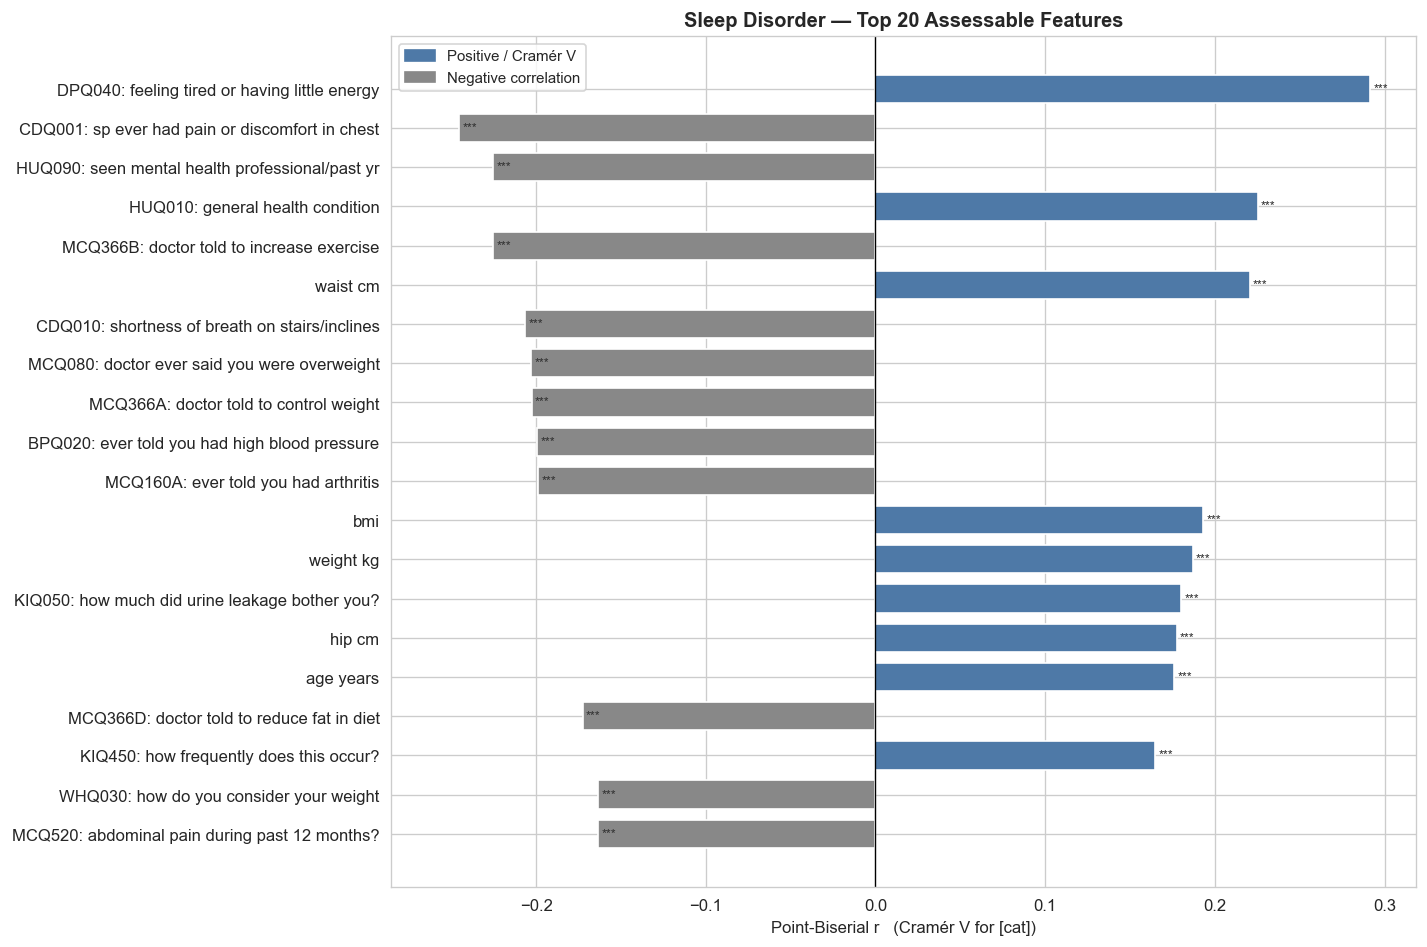

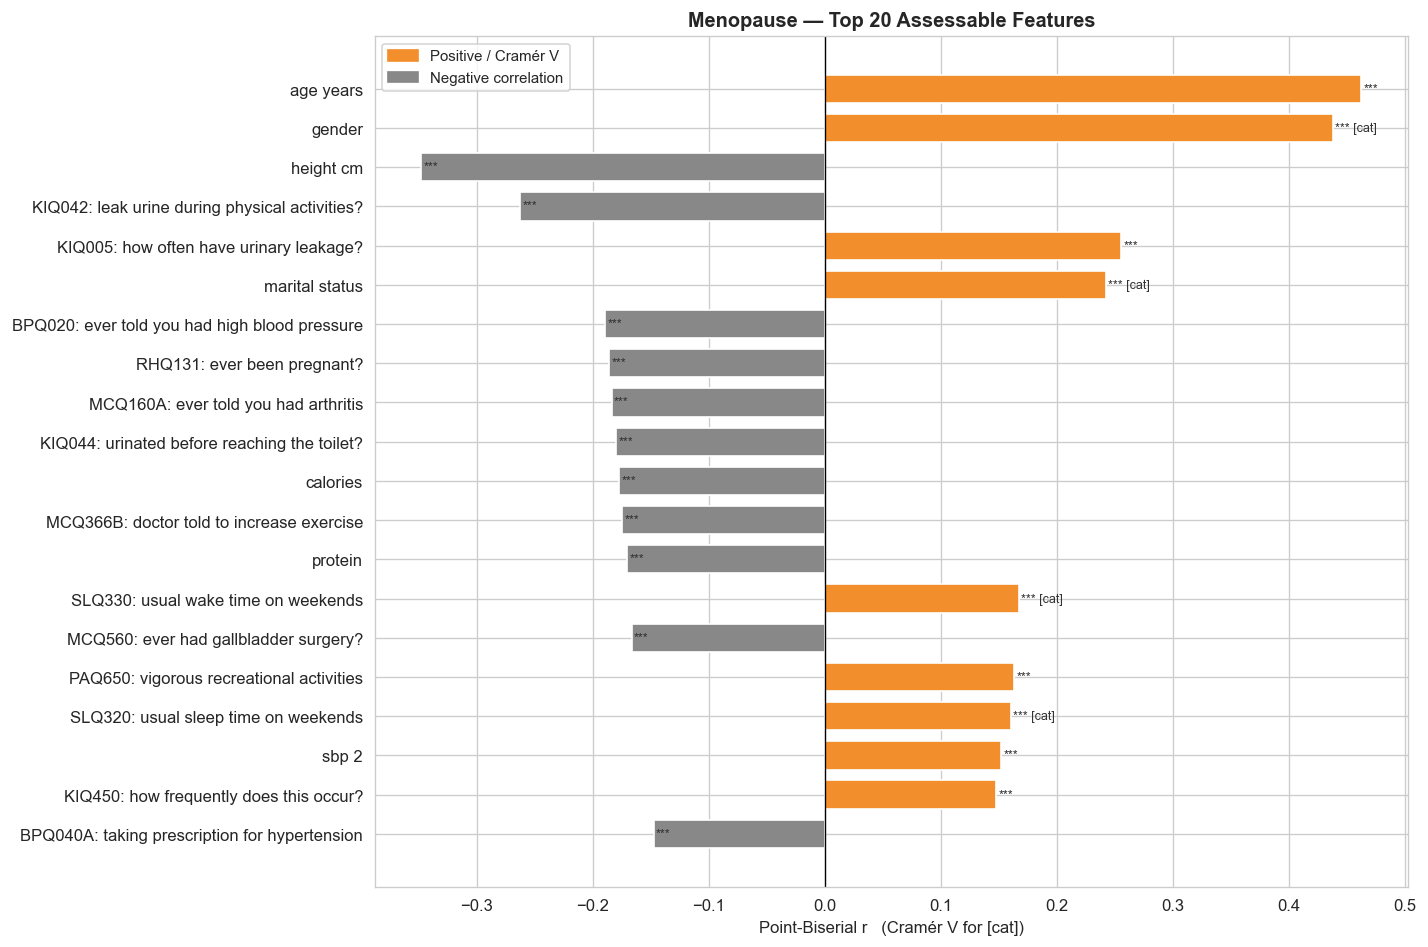

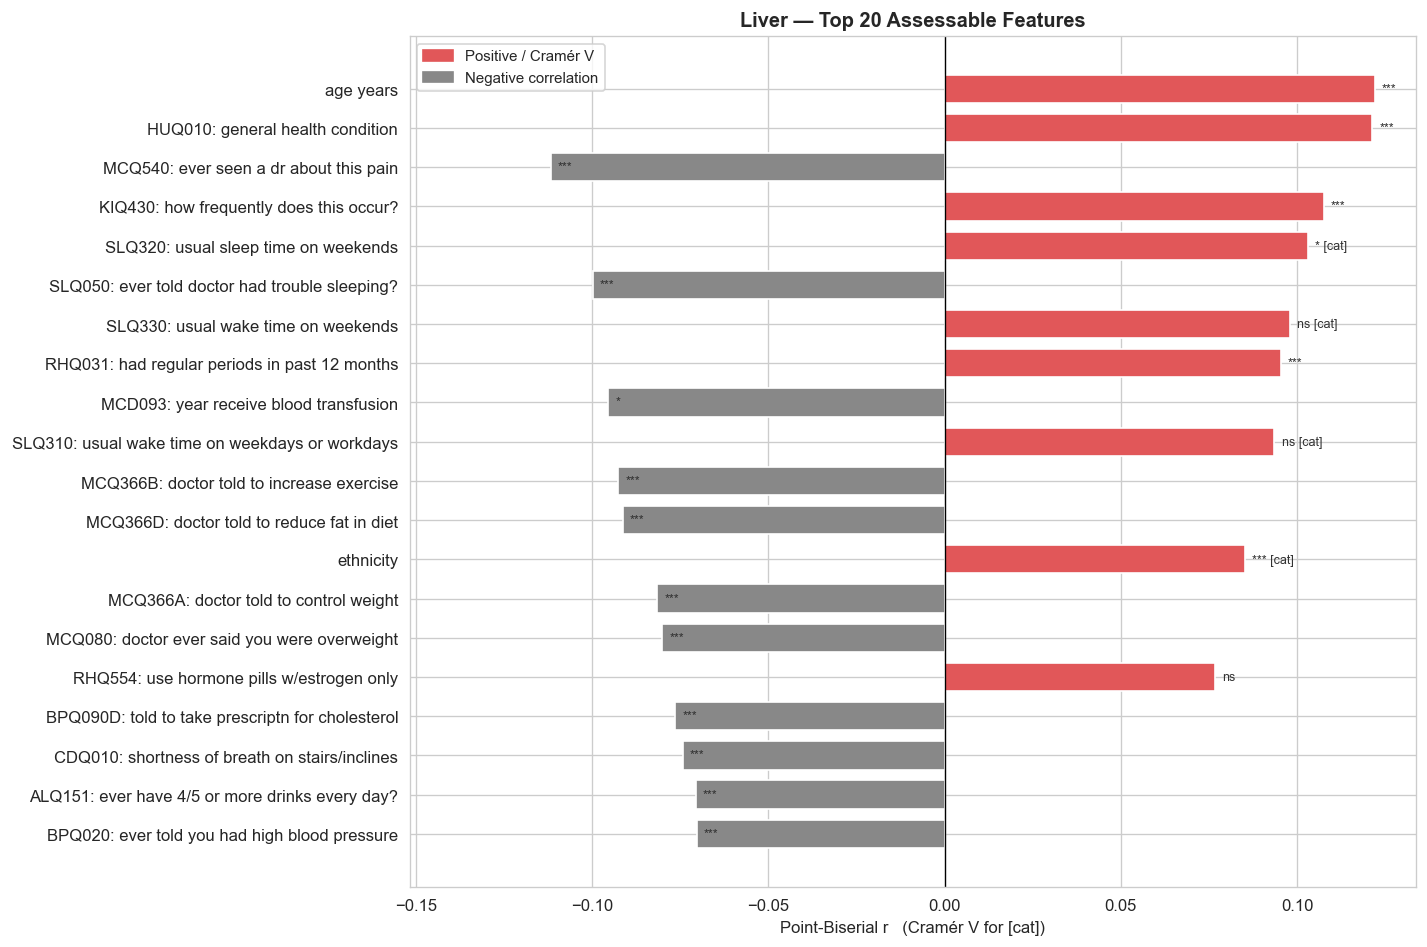

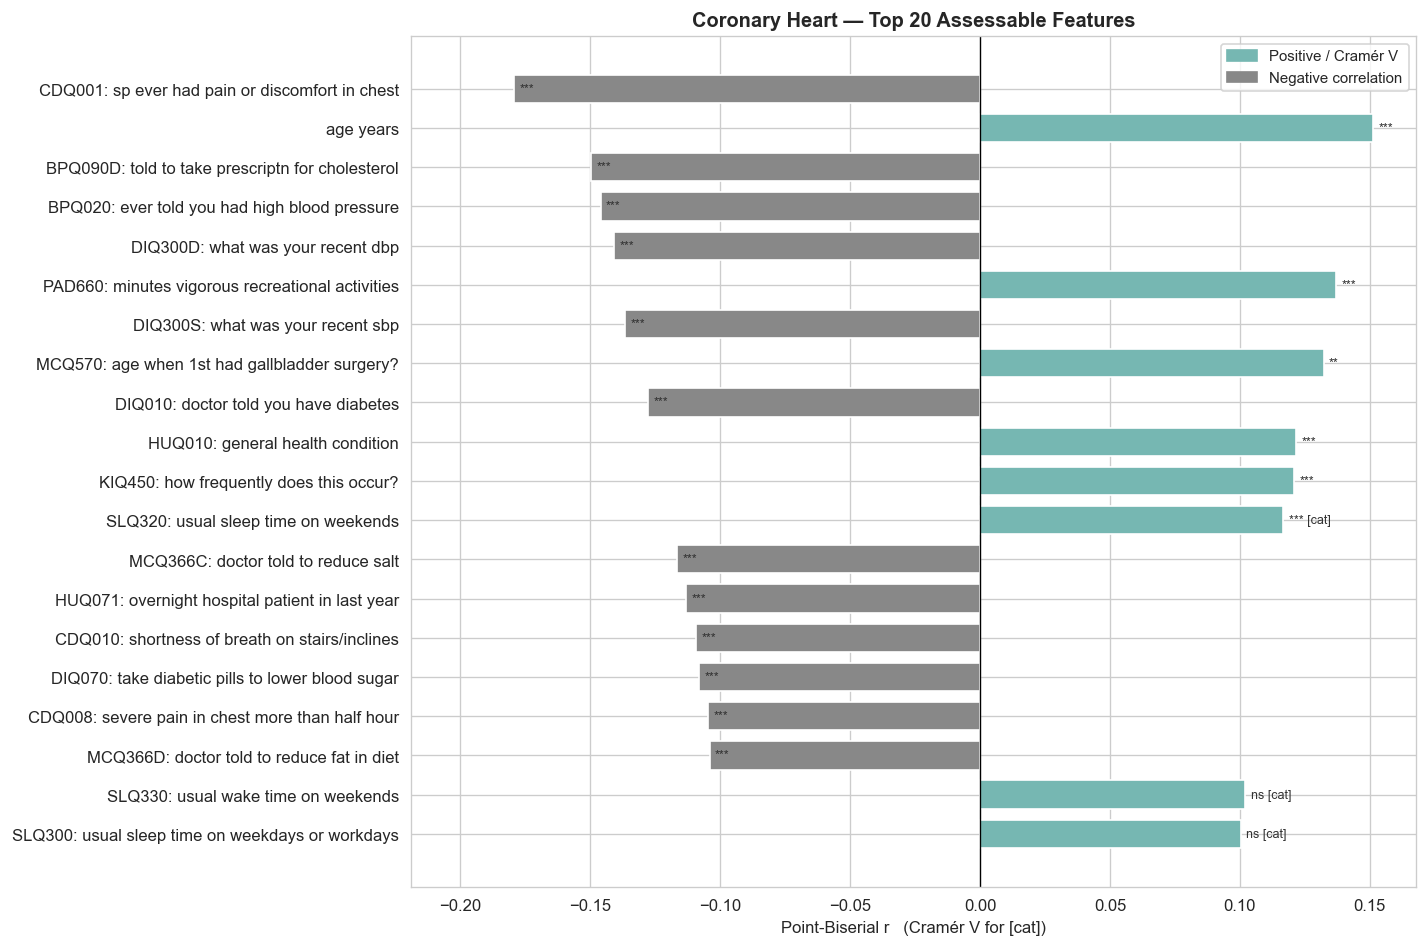

In [6]:
def plot_corr(corr_df, disease, color, top_n=20):
    top = corr_df.head(top_n).copy()
    top['label'] = top['feature'].apply(short_label)
    top['plot_r'] = top.apply(
        lambda row: row['r'] if row['type']=='numeric' else row['abs_r'], axis=1)
    top = top.sort_values('abs_r')   # ascending for barh (largest at top)

    fig, ax = plt.subplots(figsize=(12, 8))
    bar_colors = [color if r >= 0 else '#888888' for r in top['plot_r']]
    bars = ax.barh(top['label'], top['plot_r'], color=bar_colors,
                   edgecolor='white', height=0.72)

    for bar, row in zip(bars, top.itertuples()):
        tag = row.sig + (' [cat]' if row.type == 'categorical' else '')
        x = bar.get_width()
        ax.text(x + 0.002, bar.get_y() + bar.get_height()/2,
                tag, va='center', fontsize=7.5, color='#333')

    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Point-Biserial r   (Cramér V for [cat])', fontsize=10)
    ax.set_title(f'{disease.replace("_"," ").title()} — Top {top_n} Assessable Features',
                 fontsize=12, fontweight='bold')
    patches = [
        mpatches.Patch(color=color, label='Positive / Cramér V'),
        mpatches.Patch(color='#888888', label='Negative correlation'),
    ]
    ax.legend(handles=patches, fontsize=9)
    ax.set_xlim(left=min(top['plot_r'].min() - 0.04, -0.02))
    plt.tight_layout()
    plt.show()

for d in DISEASES:
    plot_corr(CORR[d], d, COLORS[d])

---
## 4. Ranked Summary Tables

In [7]:
for d in DISEASES:
    t = CORR[d].head(20).copy()
    t.index = range(1, len(t)+1)
    t['Feature'] = t['feature'].apply(short_label)
    print(f'\n{"═"*68}')
    print(f'  TOP 20 — {d.upper().replace("_"," ")}')
    print(f'{"═"*68}')
    print(t[['Feature','r','p_value','sig','type','n']]
          .rename(columns={'r':'r / V','p_value':'p-val','type':'Type'})
          .to_string(float_format='{:.4f}'.format))


════════════════════════════════════════════════════════════════════
  TOP 20 — SLEEP DISORDER
════════════════════════════════════════════════════════════════════
                                            Feature   r / V  p-val  sig     Type     n
1     DPQ040: feeling tired or having little energy  0.2917 0.0000  ***  numeric  6463
2   CDQ001: sp ever had pain or discomfort in chest -0.2453 0.0000  ***  numeric  4177
3   HUQ090: seen mental health professional/past yr -0.2254 0.0000  ***  numeric  7437
4                  HUQ010: general health condition  0.2252 0.0000  ***  numeric  7437
5         MCQ366B: doctor told to increase exercise -0.2252 0.0000  ***  numeric  7437
6                                          waist cm  0.2205 0.0000  ***  numeric  6607
7    CDQ010: shortness of breath on stairs/inclines -0.2064 0.0000  ***  numeric  4177
8      MCQ080: doctor ever said you were overweight -0.2031 0.0000  ***  numeric  7437
9            MCQ366A: doctor told to control weight 

---
## 5. Cross-Disease Feature Overlap Heatmap

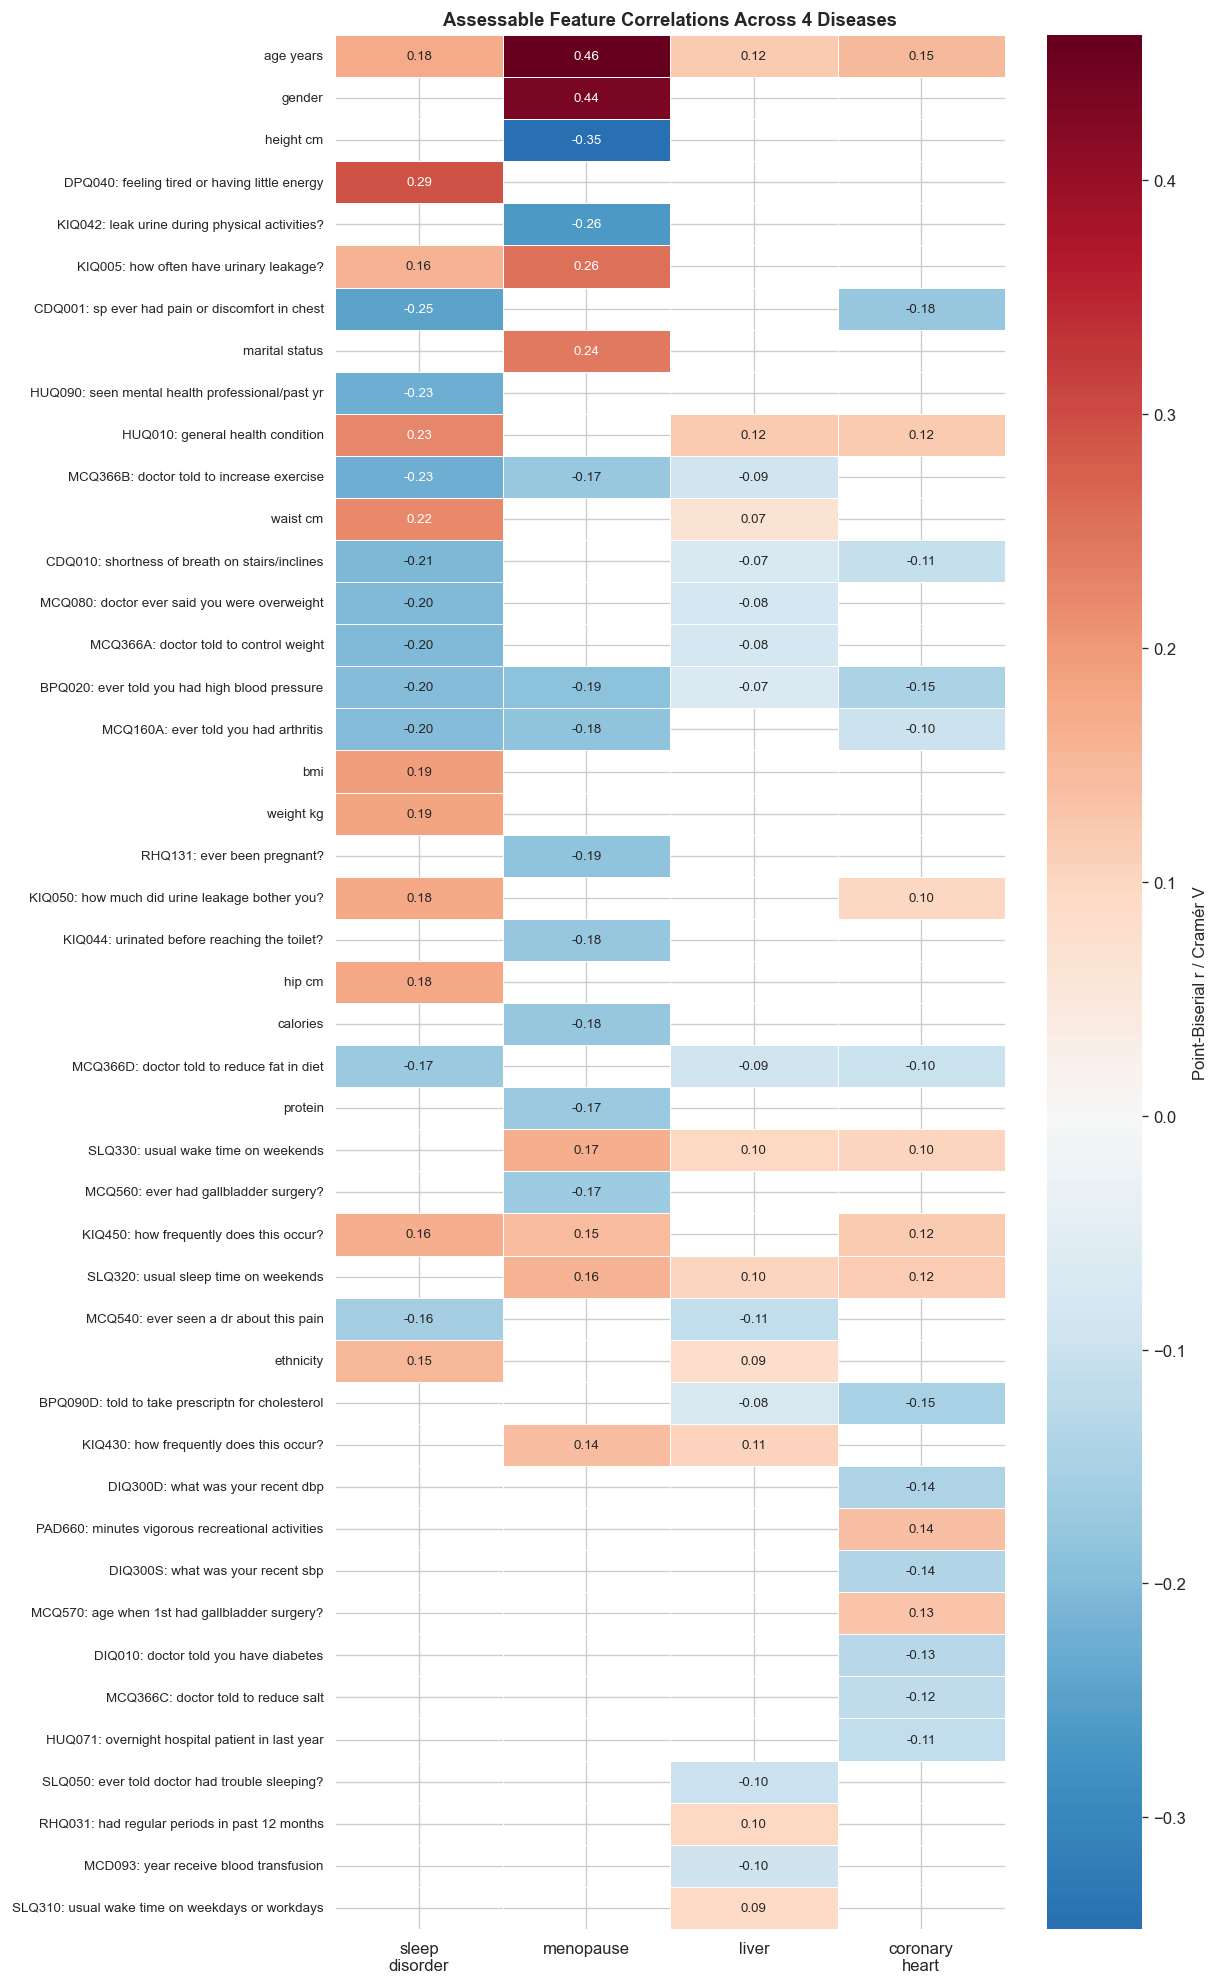


Shared top-15 features across 3+ diseases:
  age years  →  ['menopause', 'liver', 'coronary_heart']
  BPQ020: ever told you had high blood pressure  →  ['sleep_disorder', 'menopause', 'coronary_heart']
  HUQ010: general health condition  →  ['sleep_disorder', 'liver', 'coronary_heart']
  MCQ366B: doctor told to increase exercise  →  ['sleep_disorder', 'menopause', 'liver']


In [8]:
top15 = {d: set(CORR[d].head(15)['feature']) for d in DISEASES}
all_feats = sorted(set().union(*top15.values()))

hm = pd.DataFrame(index=all_feats, columns=DISEASES, dtype=float)
for d in DISEASES:
    lkp = CORR[d].set_index('feature')['r']
    for f in all_feats:
        hm.loc[f, d] = lkp.get(f, np.nan)

hm = hm.astype(float)
hm['_max'] = hm.abs().max(axis=1)
hm = hm.sort_values('_max', ascending=False).drop(columns='_max')
short_idx = [short_label(f, 50) for f in hm.index]

fig, ax = plt.subplots(figsize=(10, max(8, len(hm)*0.37)))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.35, ax=ax, yticklabels=short_idx,
            cbar_kws={'label': 'Point-Biserial r / Cramér V'},
            annot_kws={'size': 8})
ax.set_xticklabels([d.replace('_','\n') for d in DISEASES], rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_title('Assessable Feature Correlations Across 4 Diseases',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nShared top-15 features across 3+ diseases:')
for f in all_feats:
    cnt = sum(f in s for s in top15.values())
    if cnt >= 3:
        print(f'  {short_label(f,55)}  →  {[d for d in DISEASES if f in top15[d]]}')

---
## 6. Distribution Deep-Dives (Top Numeric Features per Disease)

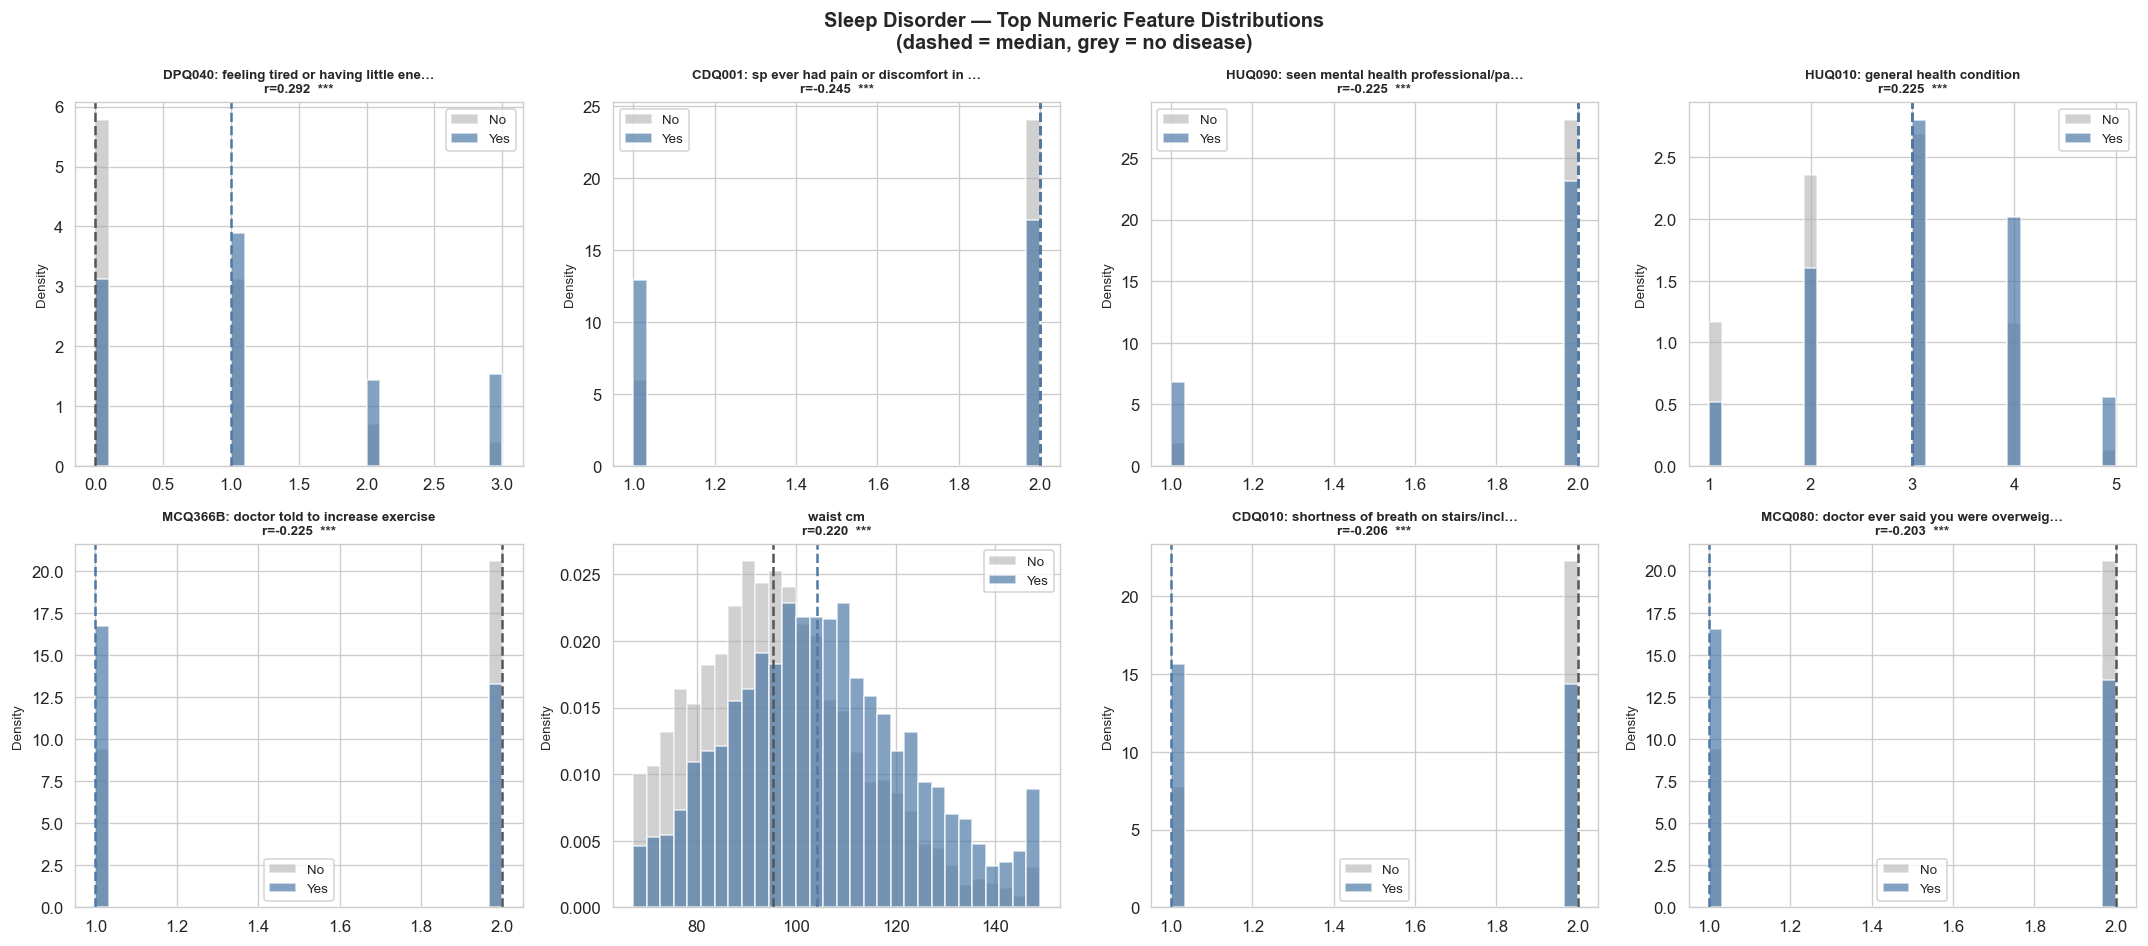

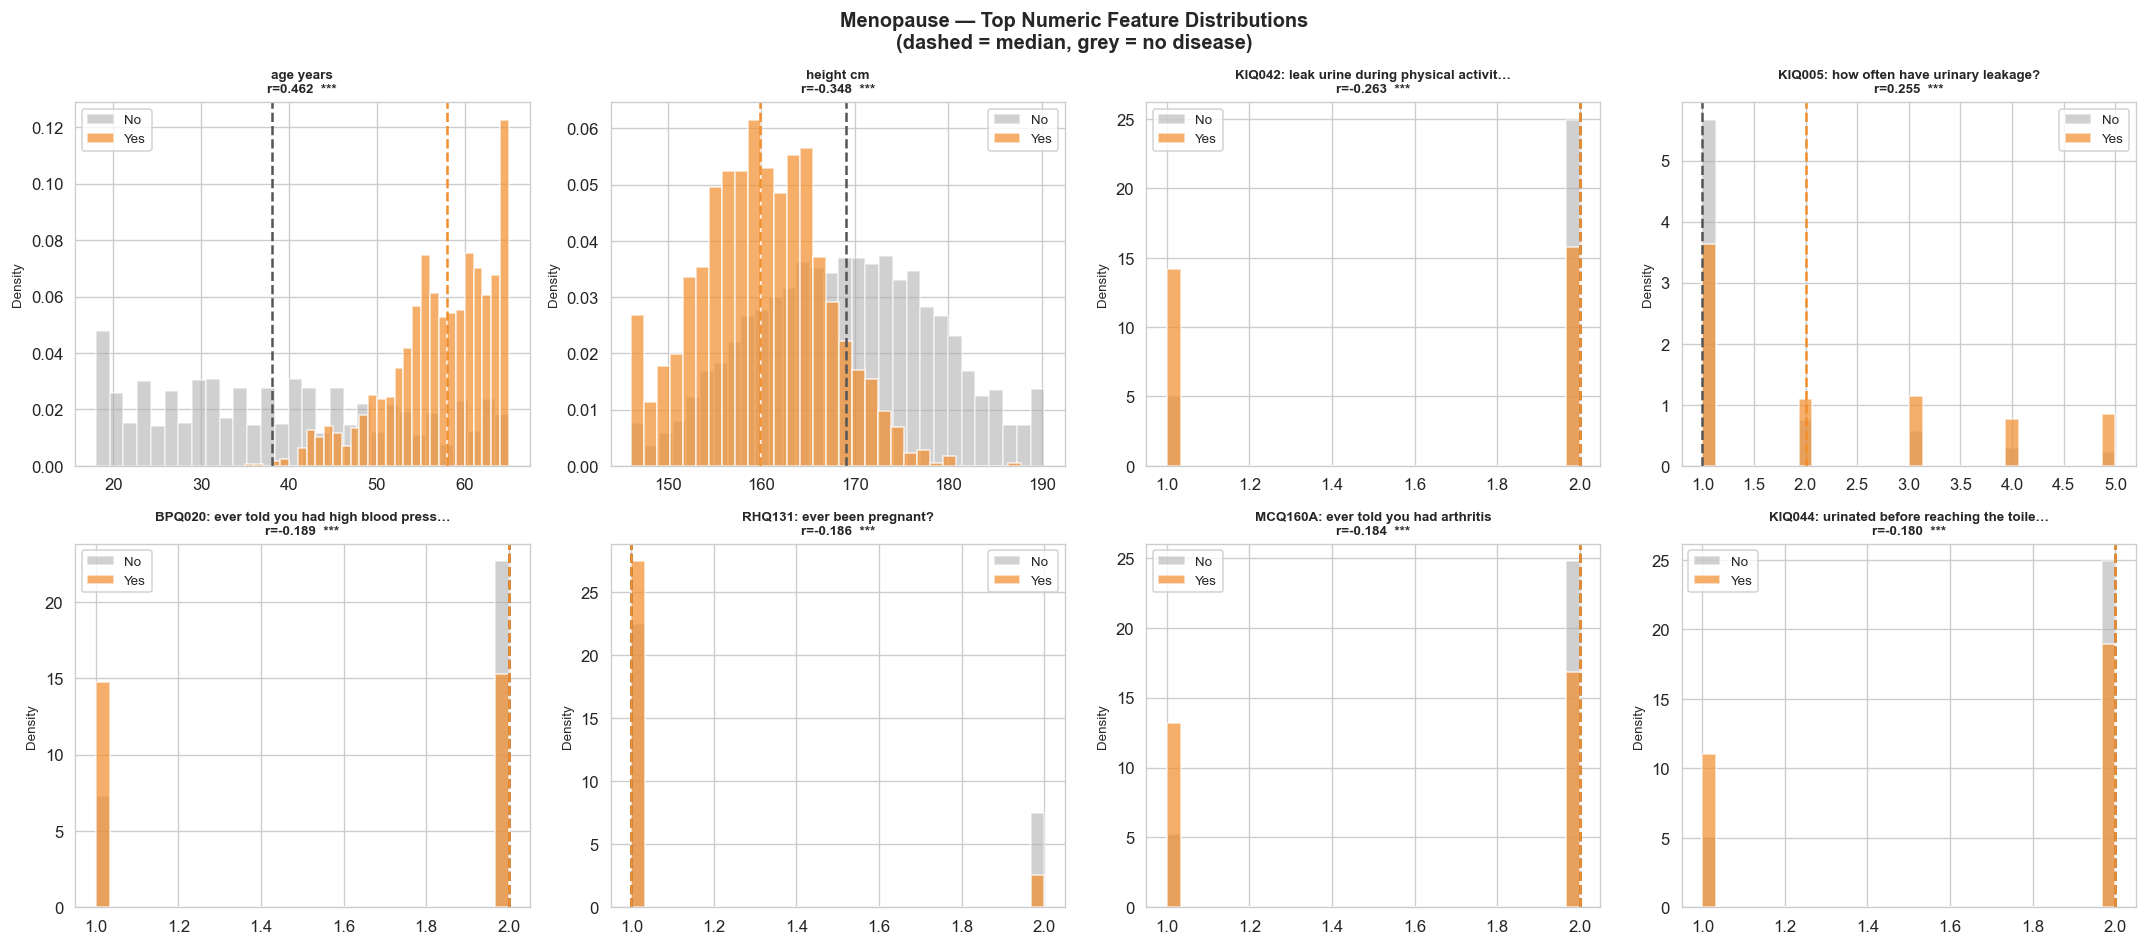

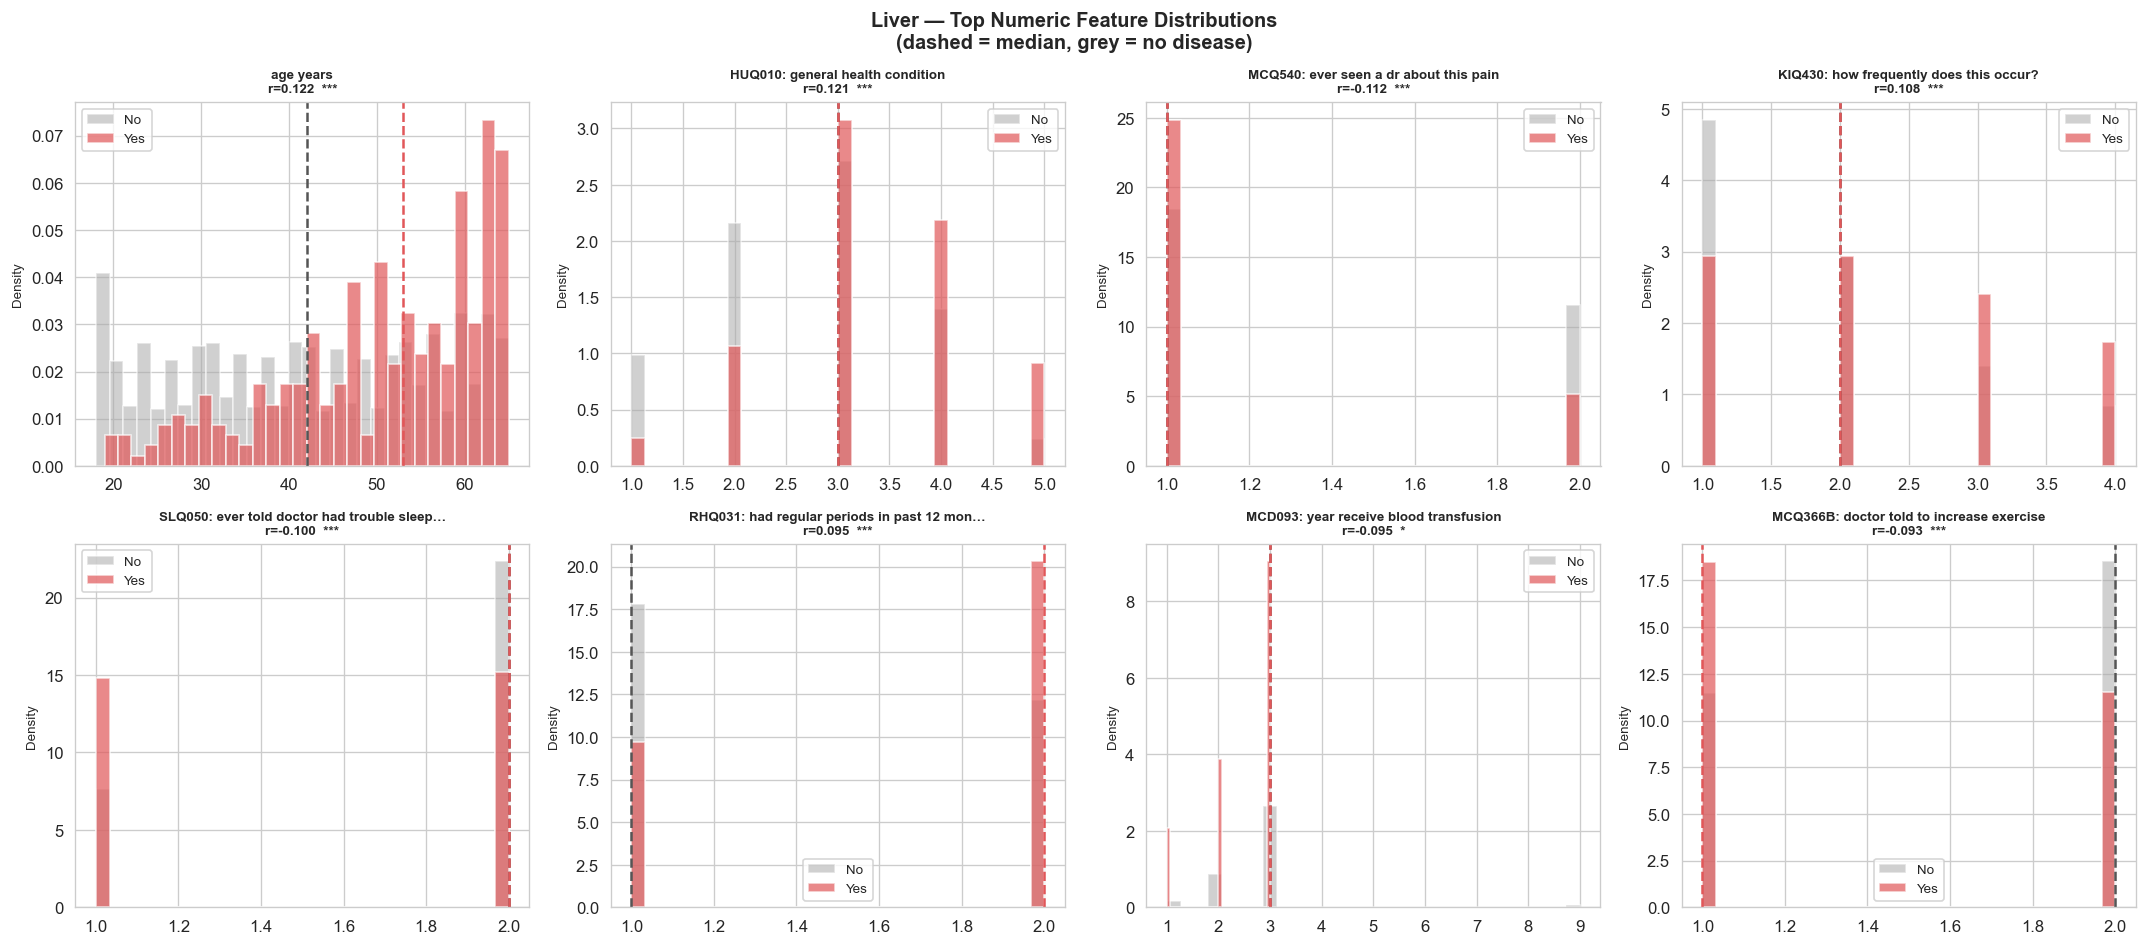

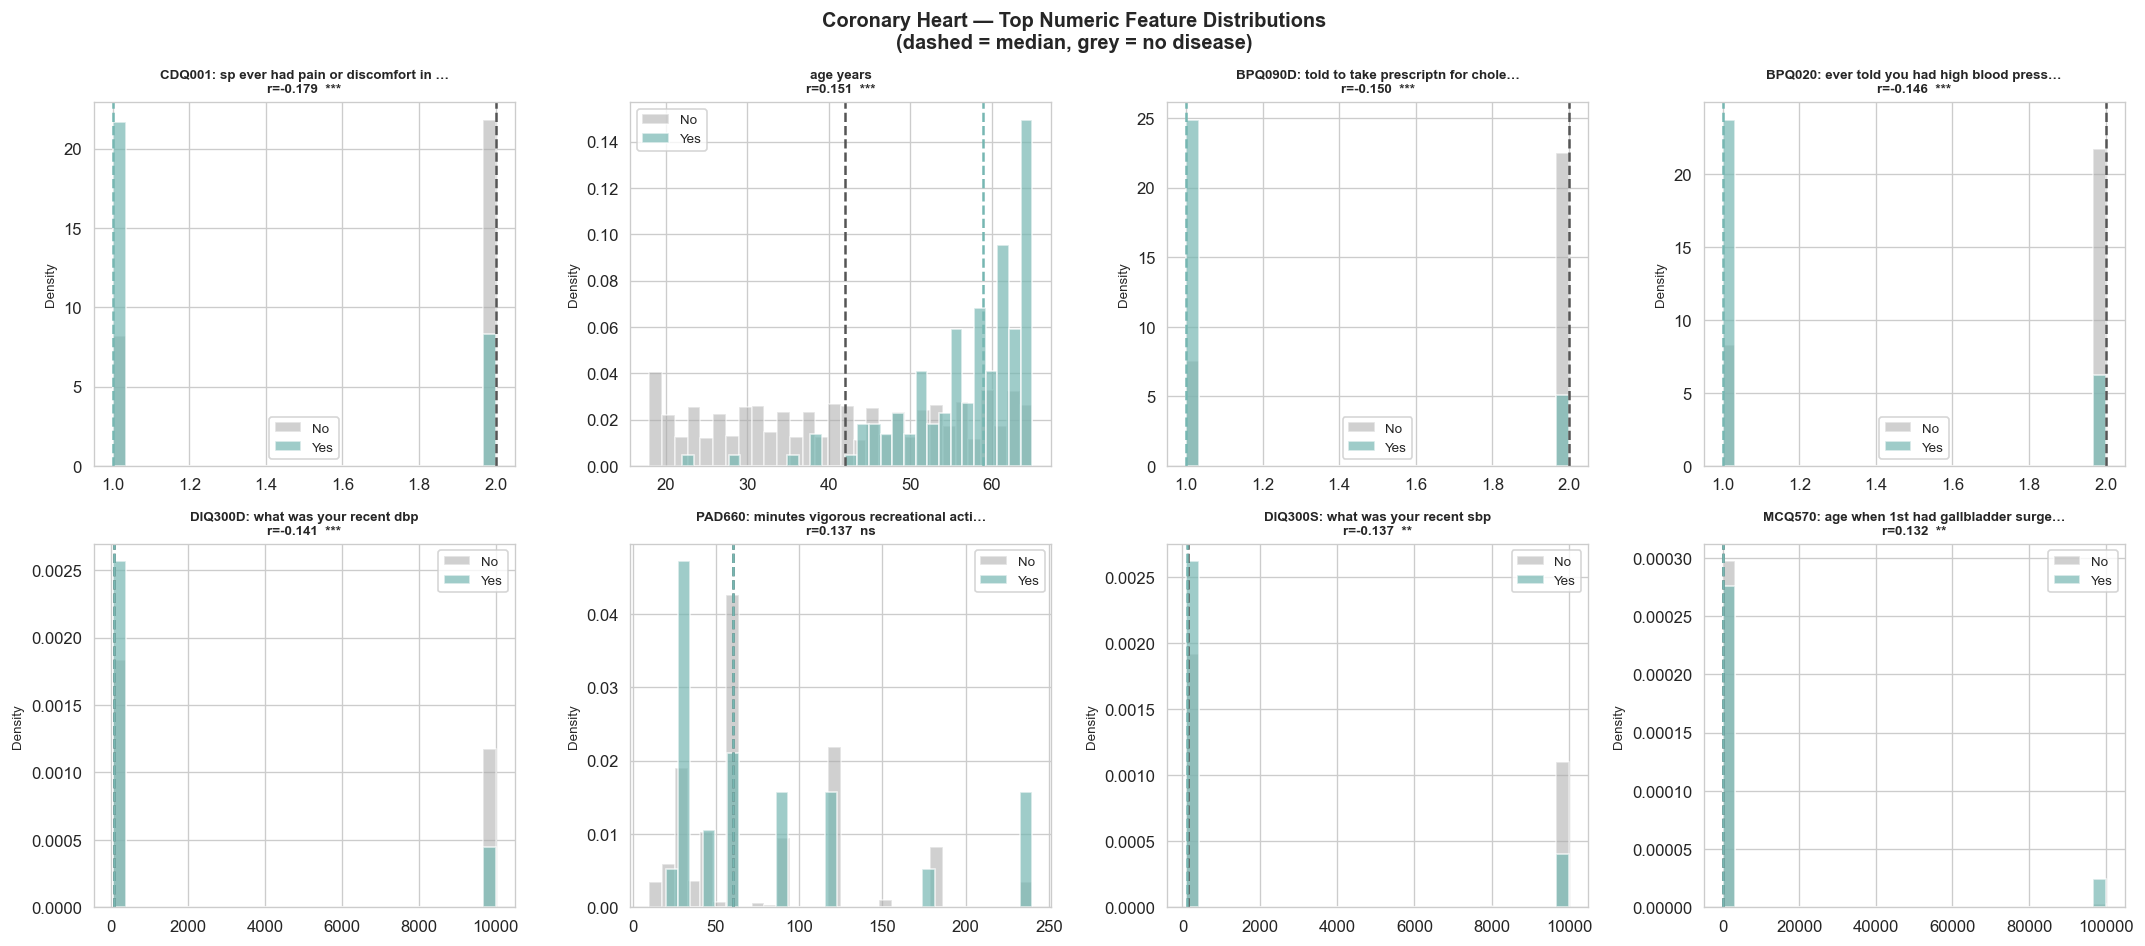

In [9]:
def plot_distributions(df, disease, corr_df, color, n=8):
    num_rows = corr_df[corr_df['type']=='numeric'].head(n)
    if len(num_rows) == 0: return
    ncols = 4
    nrows = int(np.ceil(len(num_rows)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
    axes = axes.flatten()
    for i, (_, row) in enumerate(num_rows.iterrows()):
        feat = row['feature']
        sub  = df[[feat, disease]].dropna()
        lo, hi = sub[feat].quantile(0.01), sub[feat].quantile(0.99)
        g0 = sub[sub[disease]==0][feat].clip(lo, hi)
        g1 = sub[sub[disease]==1][feat].clip(lo, hi)
        axes[i].hist(g0, bins=30, alpha=0.55, color='#aaa', label='No', density=True)
        axes[i].hist(g1, bins=30, alpha=0.70, color=color, label='Yes', density=True)
        axes[i].axvline(g0.median(), color='#555', lw=1.5, ls='--')
        axes[i].axvline(g1.median(), color=color, lw=1.5, ls='--')
        _, p = mannwhitneyu(sub[sub[disease]==0][feat].dropna(),
                            sub[sub[disease]==1][feat].dropna(), alternative='two-sided')
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        axes[i].set_title(f'{short_label(feat,42)}\nr={row["r"]:.3f}  {sig}', fontsize=8, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_ylabel('Density', fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{disease.replace("_"," ").title()} — Top Numeric Feature Distributions\n'
                 '(dashed = median, grey = no disease)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

for d in DISEASES:
    plot_distributions(df, d, CORR[d], COLORS[d])

---
## 7. Age, Gender & Fatigue Profiles per Disease

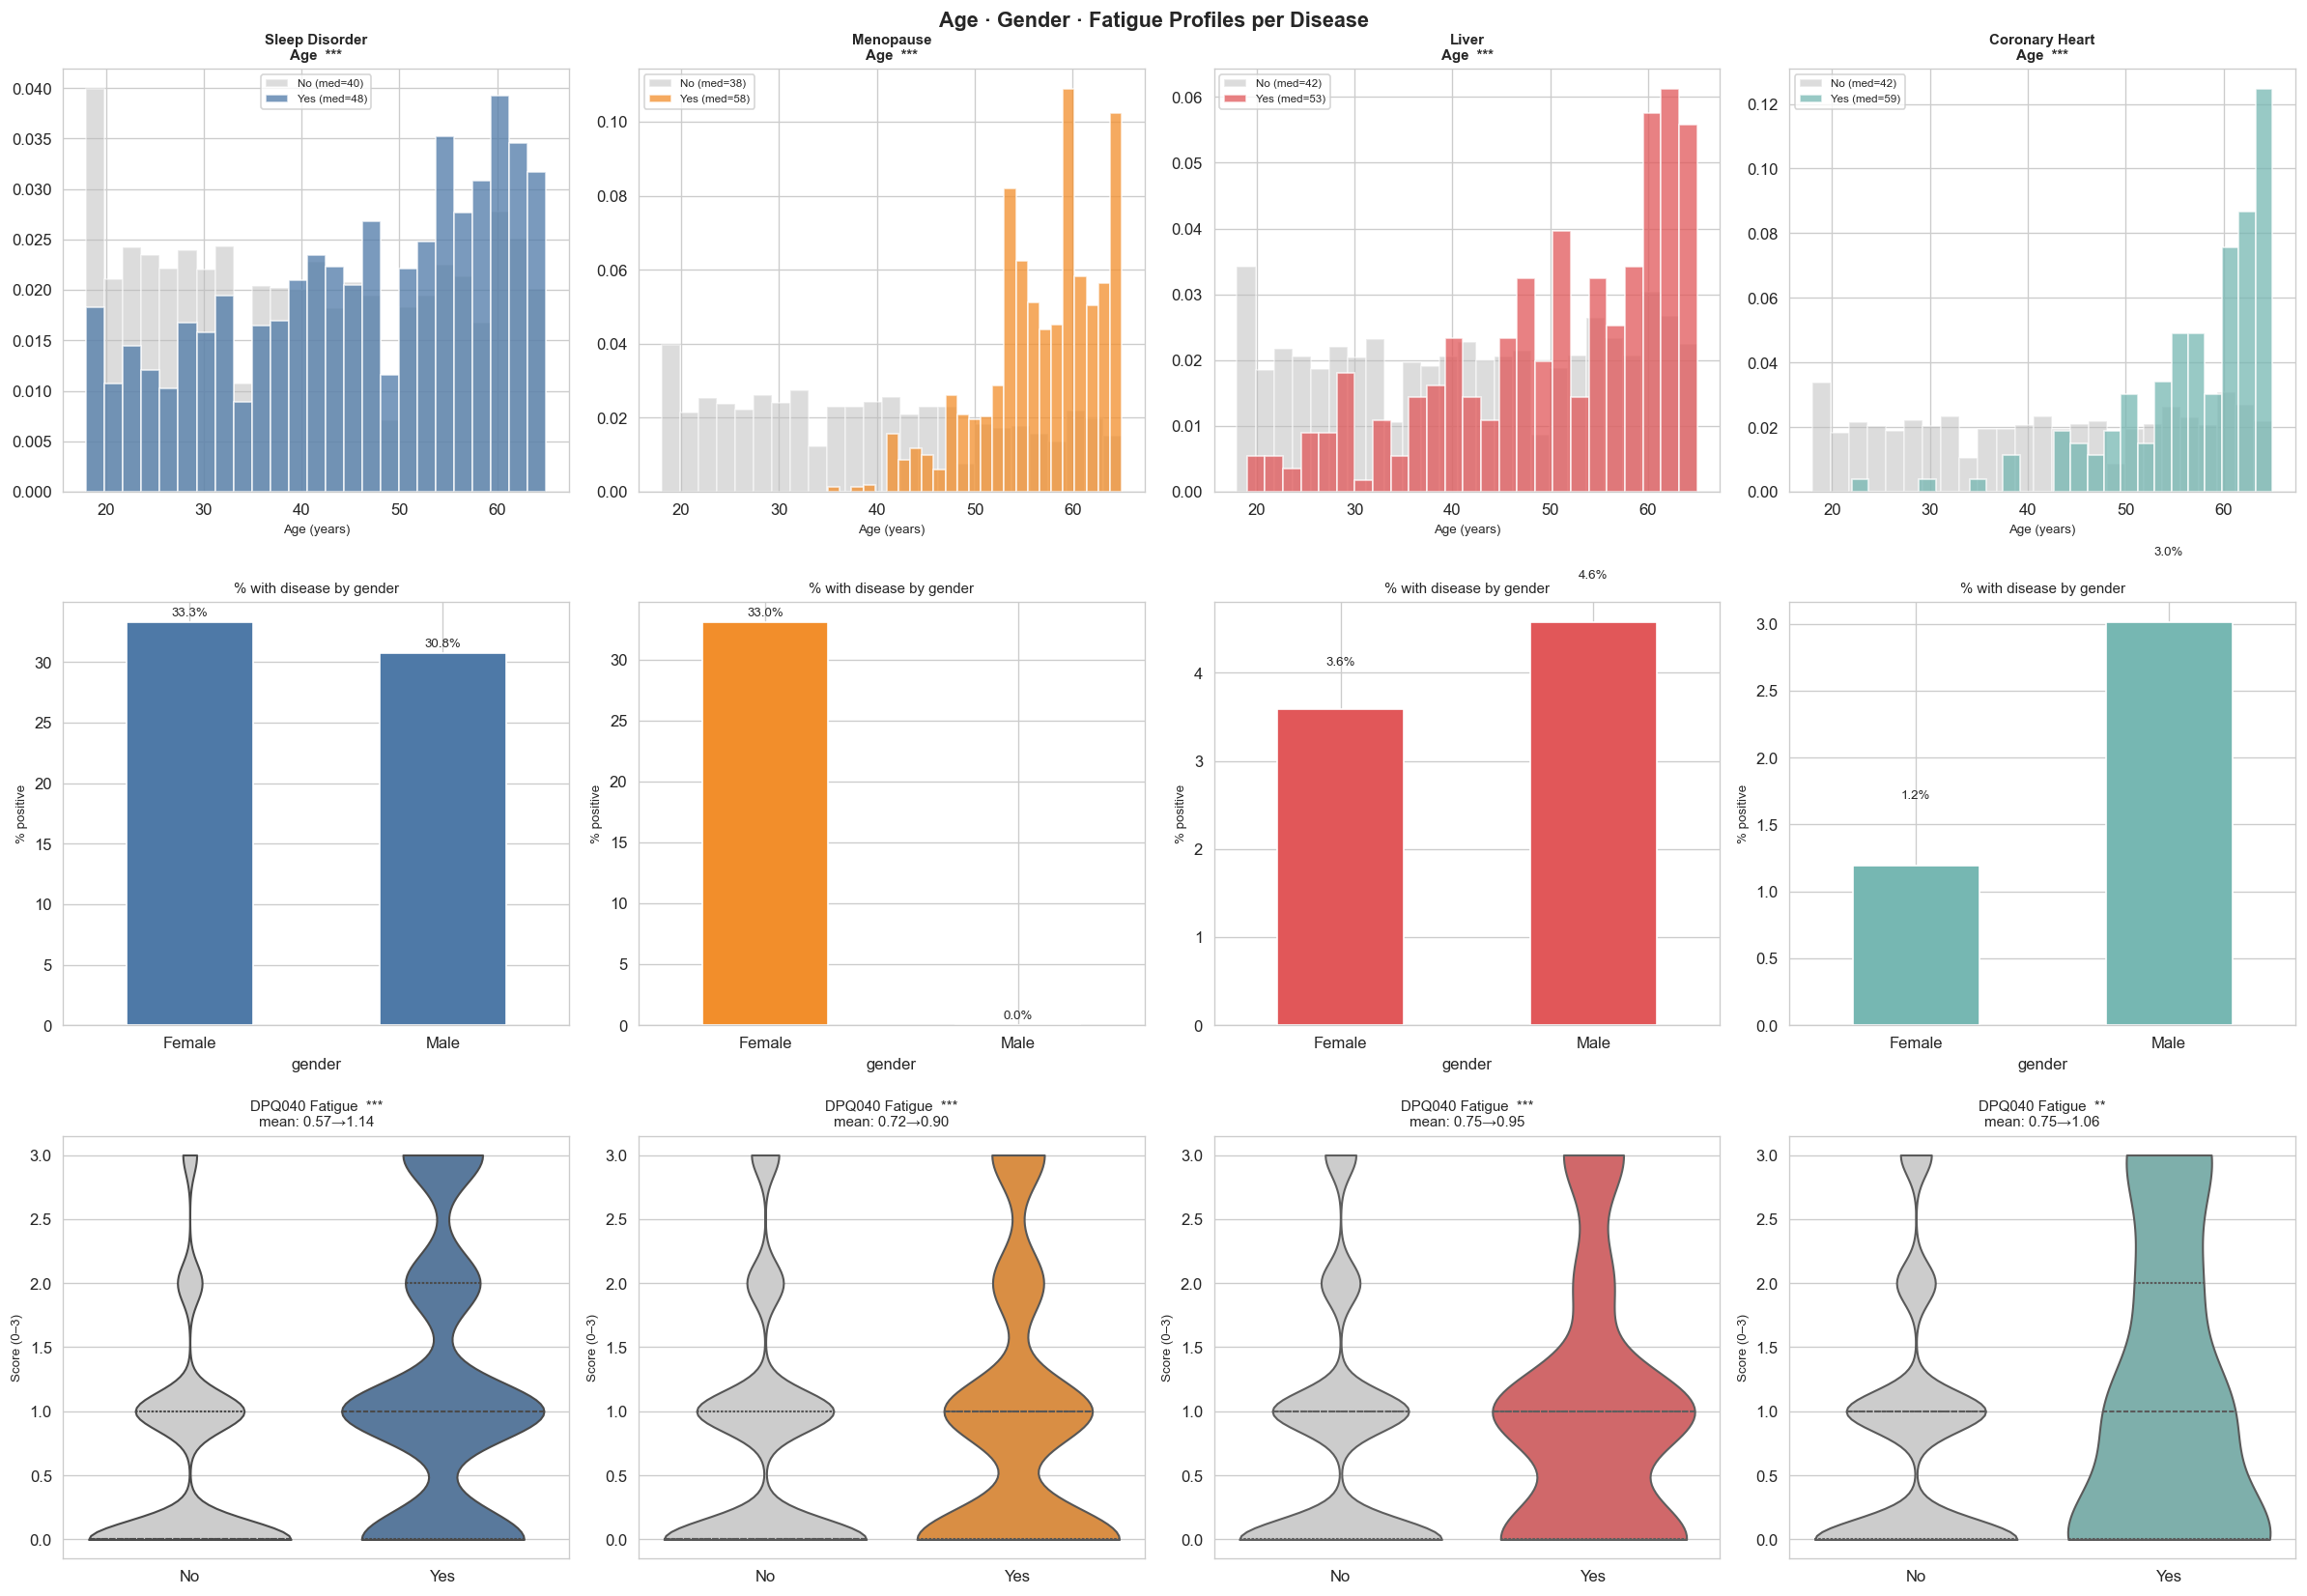

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for col, disease in enumerate(DISEASES):
    color = COLORS[disease]

    # Row 0: Age distribution
    sub = df[['age_years', disease]].dropna()
    g0, g1 = sub[sub[disease]==0]['age_years'], sub[sub[disease]==1]['age_years']
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    axes[0,col].hist(g0, bins=25, alpha=0.5, color='#bbb', density=True,
                     label=f'No (med={g0.median():.0f})')
    axes[0,col].hist(g1, bins=25, alpha=0.75, color=color, density=True,
                     label=f'Yes (med={g1.median():.0f})')
    axes[0,col].set_title(f'{disease.replace("_"," ").title()}\nAge  {sig}', fontweight='bold', fontsize=9)
    axes[0,col].set_xlabel('Age (years)', fontsize=8)
    axes[0,col].legend(fontsize=7)

    # Row 1: Gender breakdown
    sub2 = df[['gender', disease]].dropna()
    ct = pd.crosstab(sub2['gender'], sub2[disease], normalize='index') * 100
    if 1 not in ct.columns: ct[1] = 0.0
    ct[1].plot(kind='bar', ax=axes[1,col], color=color, edgecolor='white')
    axes[1,col].set_title('% with disease by gender', fontsize=9)
    axes[1,col].set_ylabel('% positive', fontsize=8)
    axes[1,col].tick_params(axis='x', rotation=0)
    for bar in axes[1,col].patches:
        axes[1,col].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                         f'{bar.get_height():.1f}%', ha='center', fontsize=8)

    # Row 2: DPQ040 fatigue violin
    sub3 = df[[TARGET_DPQ, disease]].dropna()
    g0f, g1f = sub3[sub3[disease]==0][TARGET_DPQ], sub3[sub3[disease]==1][TARGET_DPQ]
    _, pf = mannwhitneyu(g0f, g1f, alternative='two-sided')
    sigf = '***' if pf<0.001 else ('**' if pf<0.01 else ('*' if pf<0.05 else 'ns'))
    vdata = pd.DataFrame({'score': pd.concat([g0f,g1f]),
                           'group':['No']*len(g0f)+['Yes']*len(g1f)})
    sns.violinplot(data=vdata, x='group', y='score', ax=axes[2,col],
                   palette=['#ccc', color], inner='quartile', cut=0)
    axes[2,col].set_title(f'DPQ040 Fatigue  {sigf}\n'
                          f'mean: {g0f.mean():.2f}→{g1f.mean():.2f}', fontsize=9)
    axes[2,col].set_ylabel('Score (0–3)', fontsize=8)
    axes[2,col].set_xlabel('')

plt.suptitle('Age · Gender · Fatigue Profiles per Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Scenario C Baseline Models (Questionnaire Only)

  sleep_disorder          LR=0.776  RF=0.776  n_feat=33


  menopause               LR=0.981  RF=0.982  n_feat=33


  liver                   LR=0.747  RF=0.730  n_feat=32


  coronary_heart          LR=0.903  RF=0.923  n_feat=32


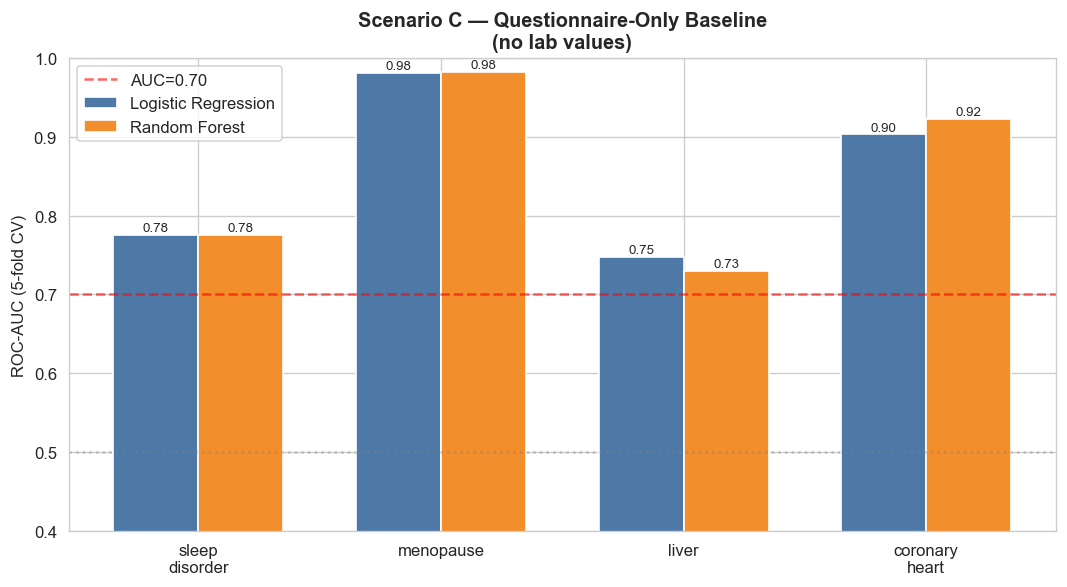

       disease    LR    RF  n_features  n_pos  n_total
sleep_disorder 0.776 0.776          33   2384     7437
     menopause 0.981 0.982          33   1271     7437
         liver 0.747 0.730          32    302     7437
coronary_heart 0.903 0.923          32    154     7437


In [11]:
# Build model-ready feature set: top 20 assessable features per disease
# plus shared demographic backbone
BACKBONE = ['age_years','gender','bmi','waist_cm','income_poverty_ratio',
            'education','marital_status','sbp_1','dbp_1',
            'smq020___smoked_at_least_100_cigarettes_in_life',
            'smq040___do_you_now_smoke_cigarettes?',
            'alq121___past_12_mo_how_often_drink_alcoholic_bev',
            'alq130___avg_#_alcoholic_drinks/day___past_12_mos',
            'pad680___minutes_sedentary_activity',
            TARGET_DPQ,
            'huq010___general_health_condition',
            'bpq020___ever_told_you_had_high_blood_pressure',
            'bpq080___doctor_told_you___high_cholesterol_level',
            'diq010___doctor_told_you_have_diabetes']
BACKBONE = [c for c in BACKBONE if c in df.columns]

df_model = df.copy()
cat_cols = [c for c in BACKBONE if not pd.api.types.is_numeric_dtype(df_model[c])]
for c in cat_cols:
    df_model[c] = LabelEncoder().fit_transform(df_model[c].astype(str))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for d in DISEASES:
    top_feats = [f for f in CORR[d].head(20)['feature']
                 if f not in EXCLUDE[d] and f in df_model.columns
                 and pd.api.types.is_numeric_dtype(df_model[f])]
    feat_set = list(dict.fromkeys(BACKBONE + top_feats))
    feat_set = [f for f in feat_set if f in df_model.columns]

    sub = df_model[feat_set + [d]].dropna(subset=[d])
    X = sub[feat_set].values   # use numpy to avoid index issues
    y = sub[d].astype(int).values

    pipe_lr = Pipeline([
        ('imp', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    ])
    pipe_rf = Pipeline([
        ('imp', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7,
                                        class_weight='balanced', random_state=42, n_jobs=-1))
    ])

    auc_lr = cross_val_score(pipe_lr, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    auc_rf = cross_val_score(pipe_rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    results.append({'disease': d, 'LR': round(auc_lr, 3), 'RF': round(auc_rf, 3),
                    'n_features': len(feat_set), 'n_pos': int(y.sum()), 'n_total': len(y)})
    print(f'  {d:<22}  LR={auc_lr:.3f}  RF={auc_rf:.3f}  n_feat={len(feat_set)}')

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(DISEASES)), 0.35
ax.bar(x - w/2, res_df['LR'], w, label='Logistic Regression', color='#4e79a7', edgecolor='white')
ax.bar(x + w/2, res_df['RF'], w, label='Random Forest',       color='#f28e2b', edgecolor='white')
ax.axhline(0.7, color='red', ls='--', alpha=0.6, label='AUC=0.70')
ax.axhline(0.5, color='grey', ls=':', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', '\n') for d in DISEASES])
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_ylim(0.4, 1.0)
ax.set_title('Scenario C — Questionnaire-Only Baseline\n(no lab values)', fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()
print(res_df.to_string(index=False))

---
## 9. ML Strategy Recommendations

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           ML STRATEGY — DISEASE PROBABILITY PREDICTION              ║
╚══════════════════════════════════════════════════════════════════════╝

SCENARIO A — All labs + all questionnaire answers
─────────────────────────────────────────────────
Model:      LightGBM / XGBoost — one binary classifier per disease
            OR shared-feature multi-label output (sigmoid)
Features:   Full assessable pool + all named labs + patterned labs
            Drop cols >60% missing; MICE for 20–60% missing
            Add is_missing_X indicator for clinically meaningful NaNs
Imbalance:  SMOTE + class_weight='balanced'; eval with PR-AUC
Expected AUC: sleep 0.80–0.88 | menopause 0.92+ | liver 0.78–0.85
              coronary_heart 0.87–0.93

SCENARIO B — Basic blood panel + structured questionnaire
─────────────────────────────────────────────────────────
Blood panel:  CBC proxies (ferritin, iron, TIBC), CMP (creatinine,
              albumin), liver enzymes (ALT/AST/GGT), lipids (TC/HDL/TG),
              fasting glucose
Questionnaire: age, gender, BMI, waist, BP, smoking, alcohol, exercise,
              diet quality, fatigue score, comorbidities
Model:        Random Forest or LightGBM (~60–80 features)
Per-disease:
  sleep_disorder: BMI + fatigue dominate; minimal blood signal → use
                  questionnaire-heavy weighting
  menopause:      age + gender is near-sufficient; blood not needed
  liver:          ALT+AST+GGT+BMI+alcohol cover 85%+ of signal
  coronary_heart: lipid panel + age + BP + smoking ≈ Framingham score
Expected AUC: ~5–8% lower than Scenario A

SCENARIO C — Text / lifestyle questionnaire only (no labs)
──────────────────────────────────────────────────────────
Core questions (25 items):
  Demographics:   age, gender, ethnicity, education, income level
  Body:           BMI (self-reported height + weight), waist size
  Vitals:         Do you know your blood pressure? (self-measured)
  Lifestyle:      smoking (ever/current), alcohol (days/week, drinks/day),
                  sedentary hours/day, work hours/week, shift work?
  Symptoms:       fatigue (0–3), chest pain on exertion, shortness of
                  breath on stairs, snoring/witnessed apnea,
                  urinary frequency at night, abdominal pain
  Diet:           perceived diet quality, fruit/veg intake,
                  fast food frequency, dietary supplement use
  History:        ever told: high BP, high cholesterol, diabetes,
                  cancer, arthritis, asthma
Model:        Logistic Regression (interpretable) or LightGBM
              Calibrate with isotonic regression
              Present output as risk percentile vs age/gender group
Per-disease expected AUC (questionnaire only):
  sleep_disorder: ~0.72–0.78 (BMI + fatigue + shift work)
  menopause:      ~0.93+    (age + gender dominate completely)
  liver:          ~0.68–0.74 (alcohol + BMI; missing enzyme data)
  coronary_heart: ~0.76–0.82 (age + gender + BP + smoking + cholesterol
                               history ≈ 80%% of Framingham factors)

CROSS-CUTTING NOTES
────────────────────
1. Build Scenario C first — ships without lab integration
2. Stratify menopause model by gender (female-only)
3. Engineer: disease_burden, non_hdl_chol, metabolic_syndrome flag,
   sleep_hours, alcohol_heavy flag, smoking_pack_years
4. Explain predictions with SHAP: top 3 risk factors per user per disease
5. Calibrate all models — tree probabilities are often poorly calibrated
6. Validate with stratified 5-fold CV + fairness checks by gender/ethnicity
""")


╔══════════════════════════════════════════════════════════════════════╗
║           ML STRATEGY — DISEASE PROBABILITY PREDICTION              ║
╚══════════════════════════════════════════════════════════════════════╝

SCENARIO A — All labs + all questionnaire answers
─────────────────────────────────────────────────
Model:      LightGBM / XGBoost — one binary classifier per disease
            OR shared-feature multi-label output (sigmoid)
Features:   Full assessable pool + all named labs + patterned labs
            Drop cols >60% missing; MICE for 20–60% missing
            Add is_missing_X indicator for clinically meaningful NaNs
Imbalance:  SMOTE + class_weight='balanced'; eval with PR-AUC
Expected AUC: sleep 0.80–0.88 | menopause 0.92+ | liver 0.78–0.85
              coronary_heart 0.87–0.93

SCENARIO B — Basic blood panel + structured questionnaire
─────────────────────────────────────────────────────────
Blood panel:  CBC proxies (ferritin, iron, TIBC), CMP (creatinine,
      

---
## 10. Mystery Fatigue EDA
### Who scores 2–3 on DPQ040 but has NONE of the 15 diseases?

These people report significant fatigue (more than half the days / nearly every day)  
yet carry none of the 15 flagged conditions. What distinguishes them?

In [13]:
# Define groups
has_zero_diseases = (df[ALL_15].sum(axis=1) == 0)
high_fatigue  = (df[TARGET_DPQ] >= 2) & has_zero_diseases
low_fatigue   = (df[TARGET_DPQ] <= 1) & has_zero_diseases

mystery = df[high_fatigue].copy()
control = df[low_fatigue].copy()

print(f'Mystery group  (fatigue 2-3, 0 diseases): n={len(mystery):,}')
print(f'Control group  (fatigue 0-1, 0 diseases): n={len(control):,}')
print(f'DPQ040 distribution in mystery group:')
print(mystery[TARGET_DPQ].value_counts().sort_index().to_dict())

Mystery group  (fatigue 2-3, 0 diseases): n=125
Control group  (fatigue 0-1, 0 diseases): n=1,427
DPQ040 distribution in mystery group:
{2.0: 87, 3.0: 38}


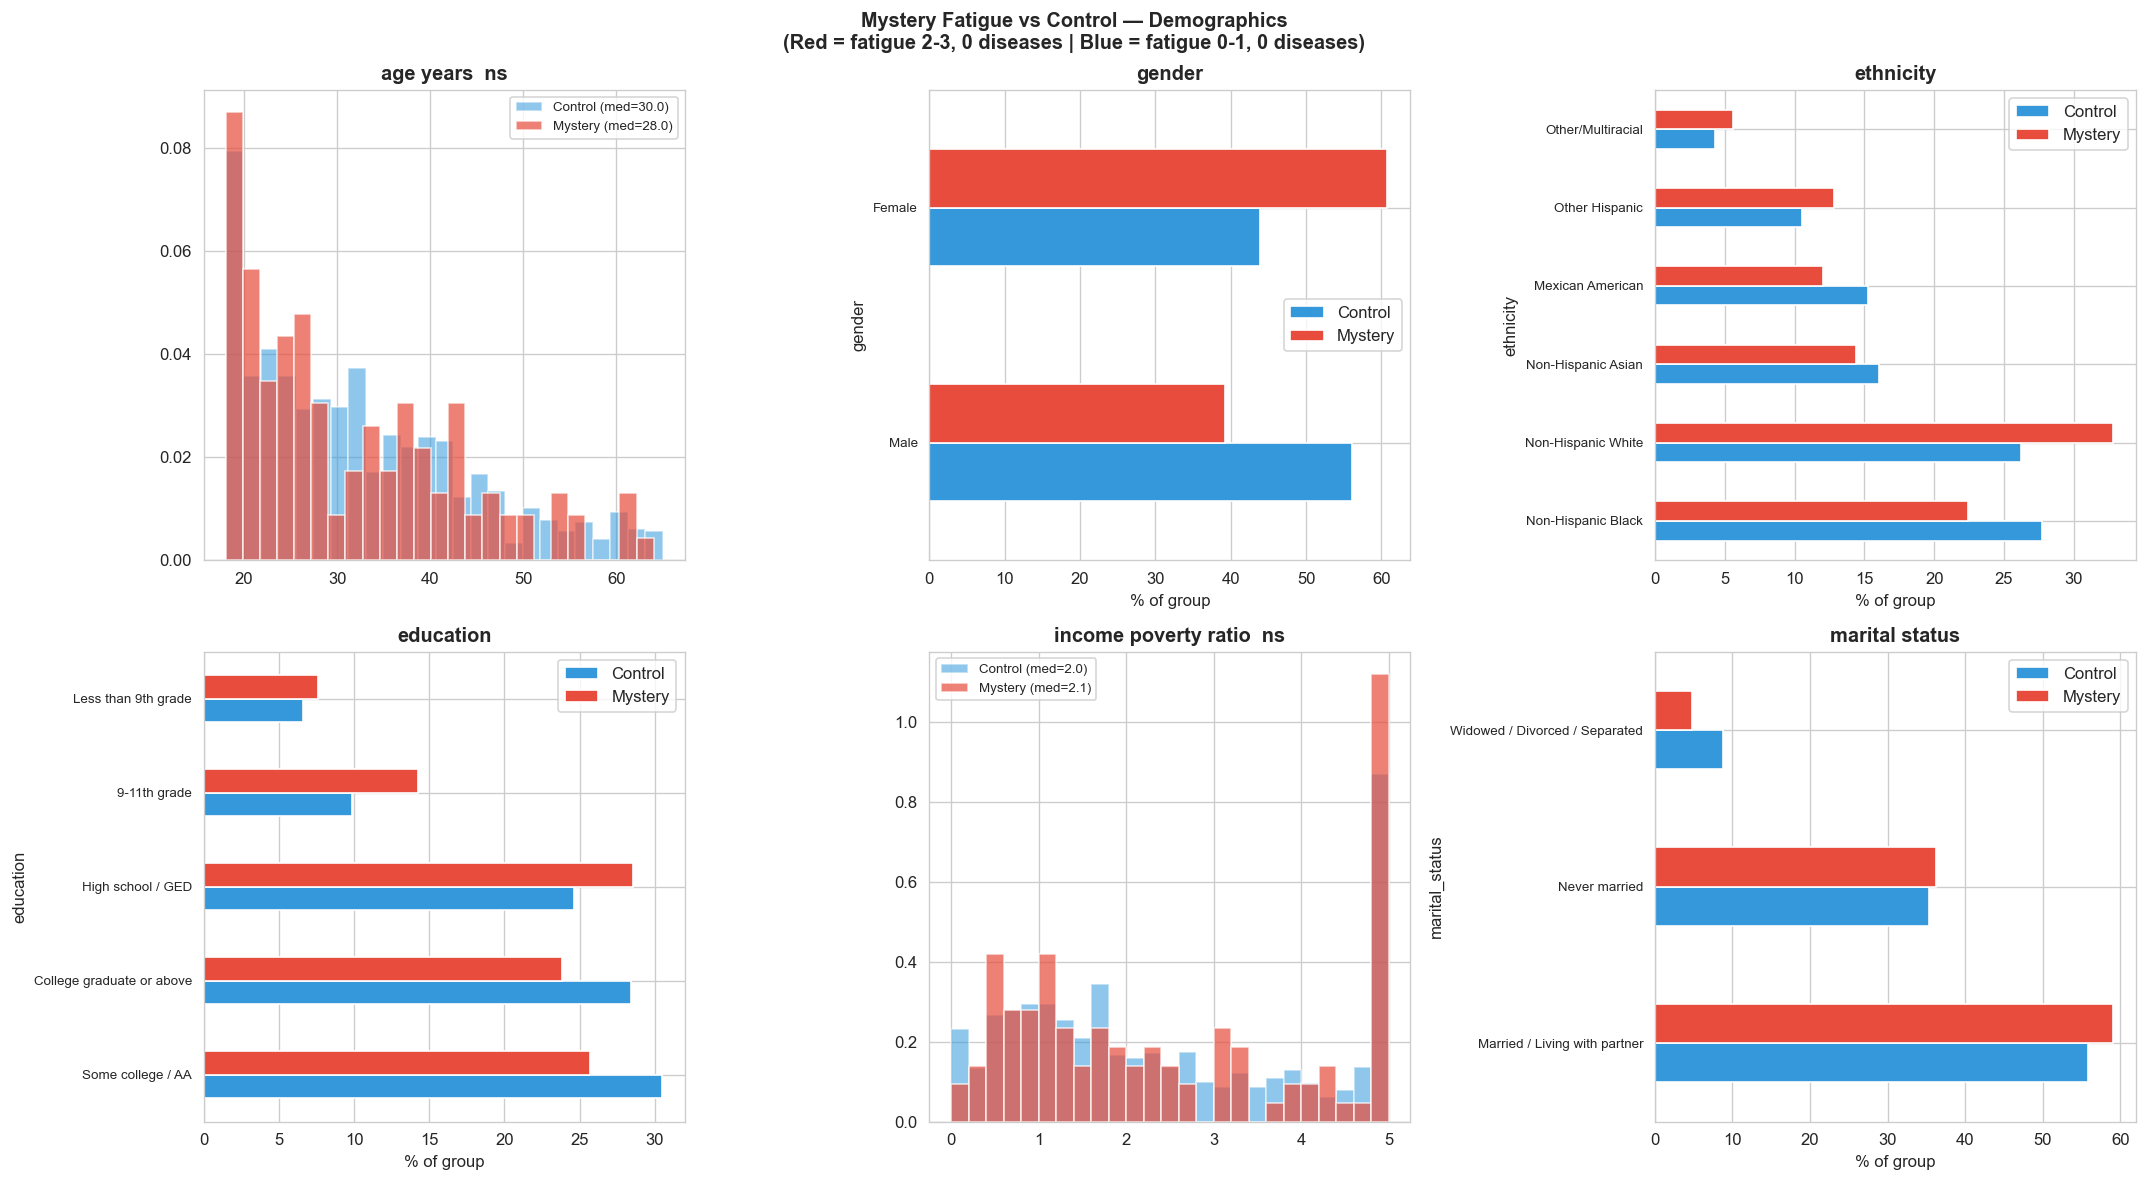

In [14]:
# ── Demographic comparison ────────────────────────────────────────────────────
demo_compare = ['age_years','gender','ethnicity','education',
                'income_poverty_ratio','marital_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feat in zip(axes, demo_compare):
    if pd.api.types.is_numeric_dtype(df[feat]):
        ax.hist(control[feat].dropna(), bins=25, alpha=0.55,
                color='#3498db', density=True, label=f'Control (med={control[feat].median():.1f})')
        ax.hist(mystery[feat].dropna(), bins=25, alpha=0.70,
                color='#e74c3c', density=True, label=f'Mystery (med={mystery[feat].median():.1f})')
        _, p = mannwhitneyu(control[feat].dropna(), mystery[feat].dropna(), alternative='two-sided')
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        ax.set_title(f'{feat.replace("_"," ")}  {sig}', fontweight='bold')
        ax.legend(fontsize=8)
    else:
        m_pct = mystery[feat].value_counts(normalize=True).rename('Mystery') * 100
        c_pct = control[feat].value_counts(normalize=True).rename('Control') * 100
        comp  = pd.concat([c_pct, m_pct], axis=1).fillna(0)
        comp.plot(kind='barh', ax=ax, color=['#3498db','#e74c3c'], edgecolor='white')
        ax.set_title(f'{feat.replace("_"," ")}', fontweight='bold')
        ax.set_xlabel('% of group')
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Mystery Fatigue vs Control — Demographics\n'
             '(Red = fatigue 2-3, 0 diseases | Blue = fatigue 0-1, 0 diseases)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

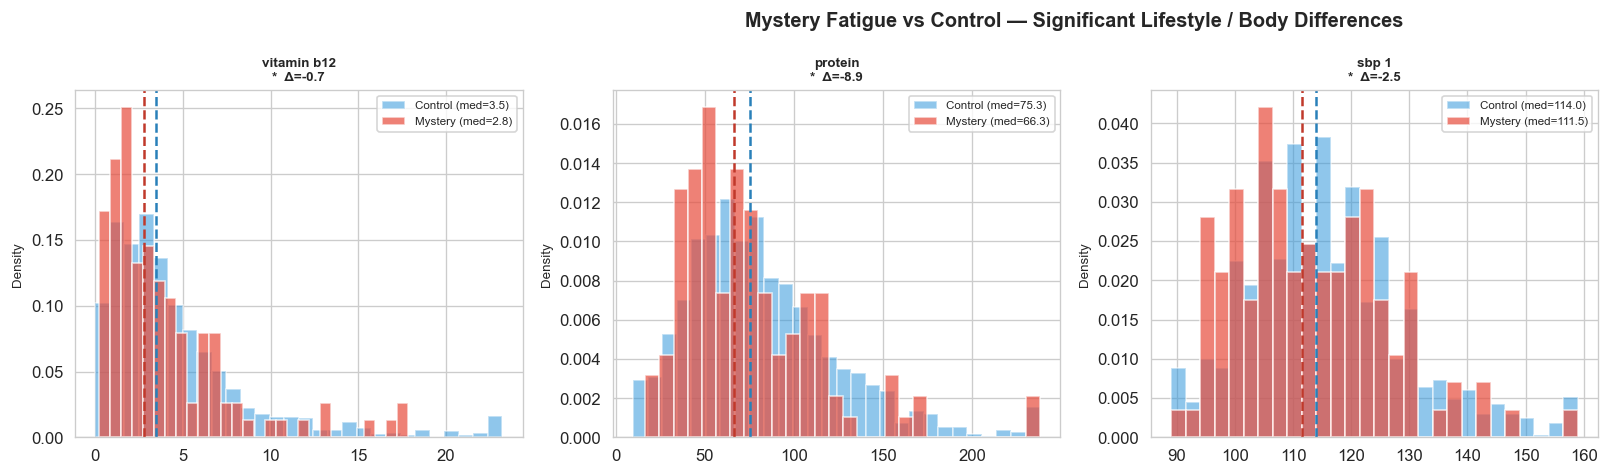

Full significance table:
                                          feature  control_median  mystery_median  delta  p_value sig
                                      vitamin_b12            3.45            2.80  -0.65 0.032832   *
                                          protein           75.28           66.34  -8.93 0.034633   *
                                            sbp_1          114.00          111.50  -2.50 0.047957   *
                                        vitamin_d            2.80            2.15  -0.65 0.057152  ns
                                             iron           12.09           11.29  -0.80 0.214657  ns
                                         calories         2055.00         2019.00 -36.00 0.408206  ns
                                            dbp_1           70.00           69.00  -1.00 0.544220  ns
              pad680___minutes_sedentary_activity          300.00          300.00   0.00 0.561881  ns
alq130___avg_#_alcoholic_drinks/day___past_12_mos        

In [15]:
# ── Lifestyle & body comparison ──────────────────────────────────────────────
lifestyle_feats = [
    'bmi', 'waist_cm', 'sbp_1', 'dbp_1',
    'calories', 'protein', 'fat', 'carbs',
    'iron', 'vitamin_b12', 'vitamin_d',
    'pad680___minutes_sedentary_activity',
    'ocq180___hours_worked_last_week_in_total_all_jobs',
    'alq130___avg_#_alcoholic_drinks/day___past_12_mos',
]
lifestyle_feats = [c for c in lifestyle_feats if c in df.columns]

stats_rows = []
for feat in lifestyle_feats:
    g_c = control[feat].dropna()
    g_m = mystery[feat].dropna()
    if len(g_c) < 10 or len(g_m) < 10:
        continue
    _, p = mannwhitneyu(g_c, g_m, alternative='two-sided')
    stats_rows.append({'feature': feat,
                        'control_median': round(g_c.median(), 2),
                        'mystery_median': round(g_m.median(), 2),
                        'delta': round(g_m.median() - g_c.median(), 2),
                        'p_value': p,
                        'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))})

stats_df = pd.DataFrame(stats_rows).sort_values('p_value')
sig_feats = [r['feature'] for _, r in stats_df.iterrows() if r['p_value'] < 0.05]

ncols = 4
nrows = int(np.ceil(len(sig_feats[:12]) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()

for i, feat in enumerate(sig_feats[:12]):
    g_c = control[feat].dropna()
    g_m = mystery[feat].dropna()
    lo = pd.concat([g_c, g_m]).quantile(0.01)
    hi = pd.concat([g_c, g_m]).quantile(0.99)
    axes[i].hist(g_c.clip(lo,hi), bins=28, alpha=0.55, color='#3498db', density=True,
                 label=f'Control (med={g_c.median():.1f})')
    axes[i].hist(g_m.clip(lo,hi), bins=28, alpha=0.70, color='#e74c3c', density=True,
                 label=f'Mystery (med={g_m.median():.1f})')
    axes[i].axvline(g_c.median(), color='#2980b9', lw=1.5, ls='--')
    axes[i].axvline(g_m.median(), color='#c0392b', lw=1.5, ls='--')
    row = stats_df[stats_df['feature']==feat].iloc[0]
    axes[i].set_title(f'{short_label(feat,40)}\n{row["sig"]}  Δ={row["delta"]:+.1f}',
                      fontsize=8, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Density', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Mystery Fatigue vs Control — Significant Lifestyle / Body Differences',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Full significance table:')
print(stats_df.to_string(index=False))

In [16]:
# ── Symptom & questionnaire comparison ──────────────────────────────────────
symptom_feats = [
    'huq010___general_health_condition',
    'huq090___seen_mental_health_professional/past_yr',
    'huq071___overnight_hospital_patient_in_last_year',
    'cdq001___sp_ever_had_pain_or_discomfort_in_chest',
    'cdq010___shortness_of_breath_on_stairs/inclines',
    'mcq010___ever_been_told_you_have_asthma',
    'mcq035___still_have_asthma',
    'kiq005___how_often_have_urinary_leakage?',
    'kiq480___how_many_times_urinate_in_night?',
    'mcq520___abdominal_pain_during_past_12_months?',
    'mcq160a___ever_told_you_had_arthritis',
    'whq070___tried_to_lose_weight_in_past_year',
    'ocq670___overall_work_schedule_past_3_months',
    'paq650___vigorous_recreational_activities',
    'smq040___do_you_now_smoke_cigarettes?',
]
symptom_feats = [c for c in symptom_feats if c in df.columns]

sym_rows = []
for feat in symptom_feats:
    all_sub = pd.concat([mystery[[feat]].assign(group='Mystery'),
                          control[[feat]].assign(group='Control')])
    sub = all_sub.dropna(subset=[feat])
    if len(sub) < 20: continue
    if pd.api.types.is_numeric_dtype(df[feat]):
        g_c = sub[sub['group']=='Control'][feat]
        g_m = sub[sub['group']=='Mystery'][feat]
        if len(g_c) > 5 and len(g_m) > 5:
            _, p = mannwhitneyu(g_c, g_m, alternative='two-sided')
            sym_rows.append({'feature': feat,
                              'control': f'{g_c.mean():.2f}',
                              'mystery': f'{g_m.mean():.2f}',
                              'p_value': p,
                              'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))})
    else:
        ct = pd.crosstab(sub[feat], sub['group'])
        if ct.shape[0] >= 2 and ct.shape[1] >= 2:
            chi2, p, _, _ = chi2_contingency(ct)
            sym_rows.append({'feature': feat,
                              'control': '(cat)', 'mystery': '(cat)',
                              'p_value': p,
                              'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))})

sym_df = pd.DataFrame(sym_rows).sort_values('p_value')
print('Symptom / questionnaire differences (Mystery vs Control):')
sym_df['label'] = sym_df['feature'].apply(short_label)
print(sym_df[['label','control','mystery','sig']].to_string(index=False))

Symptom / questionnaire differences (Mystery vs Control):
                                          label control mystery sig
  MCQ520: abdominal pain during past 12 months?    1.89    1.72 ***
               HUQ010: general health condition    2.21    2.54  **
HUQ090: seen mental health professional/past yr    1.95    1.90   *
           MCQ160A: ever told you had arthritis    1.97    1.92   *
                      MCQ035: still have asthma    1.62    1.26   *
HUQ071: overnight hospital patient in last year    1.96    1.91   *
       PAQ650: vigorous recreational activities    1.55    1.63  ns
    OCQ670: overall work schedule past 3 months    2.82    3.07  ns
CDQ001: sp ever had pain or discomfort in chest    1.87    1.77  ns
      WHQ070: tried to lose weight in past year    1.70    1.63  ns
         MCQ010: ever been told you have asthma    1.89    1.85  ns
       KIQ480: how many times urinate in night?    0.84    1.01  ns
 CDQ010: shortness of breath on stairs/inclines    1.91   

In [17]:
# ── Work schedule & activity comparison ──────────────────────────────────────
work_feats = [
    'ocq180___hours_worked_last_week_in_total_all_jobs',
    'ocq210___usually_work_35_or_more_hours_per_week',
    'ocq670___overall_work_schedule_past_3_months',
    'pad680___minutes_sedentary_activity',
    'paq605___vigorous_work_activity',
    'paq620___moderate_work_activity',
    'paq650___vigorous_recreational_activities',
    'paq665___moderate_recreational_activities',
    'pad660___minutes_vigorous_recreational_activities',
    'pad675___minutes_moderate_recreational_activities',
]
work_feats = [c for c in work_feats if c in df.columns
              and pd.api.types.is_numeric_dtype(df[c])]

work_rows = []
for feat in work_feats:
    g_c, g_m = control[feat].dropna(), mystery[feat].dropna()
    if len(g_c) < 10 or len(g_m) < 10: continue
    _, p = mannwhitneyu(g_c, g_m, alternative='two-sided')
    work_rows.append({'feature': short_label(feat, 45),
                       'control_med': round(g_c.median(),1),
                       'mystery_med': round(g_m.median(),1),
                       'delta': round(g_m.median()-g_c.median(),1),
                       'p_value': round(p, 4),
                       'sig': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))})

work_df = pd.DataFrame(work_rows).sort_values('p_value')
print('Work / activity differences (Mystery vs Control):')
print(work_df.to_string(index=False))

Work / activity differences (Mystery vs Control):
                                       feature  control_med  mystery_med  delta  p_value sig
      PAQ650: vigorous recreational activities          2.0          2.0    0.0   0.0824  ns
   OCQ670: overall work schedule past 3 months          2.0          3.0    1.0   0.1044  ns
                PAQ620: moderate work activity          2.0          2.0    0.0   0.2523  ns
            PAD680: minutes sedentary activity        300.0        300.0    0.0   0.5619  ns
OCQ180: hours worked last week in total all j…         40.0         40.0    0.0   0.5976  ns
PAD675: minutes moderate recreational activit…         60.0         45.0  -15.0   0.6559  ns
OCQ210: usually work 35 or more hours per wee…          2.0          2.0    0.0   0.7838  ns
      PAQ665: moderate recreational activities          2.0          2.0    0.0   0.8364  ns
                PAQ605: vigorous work activity          2.0          2.0    0.0   0.9617  ns
PAD660: minutes vigo

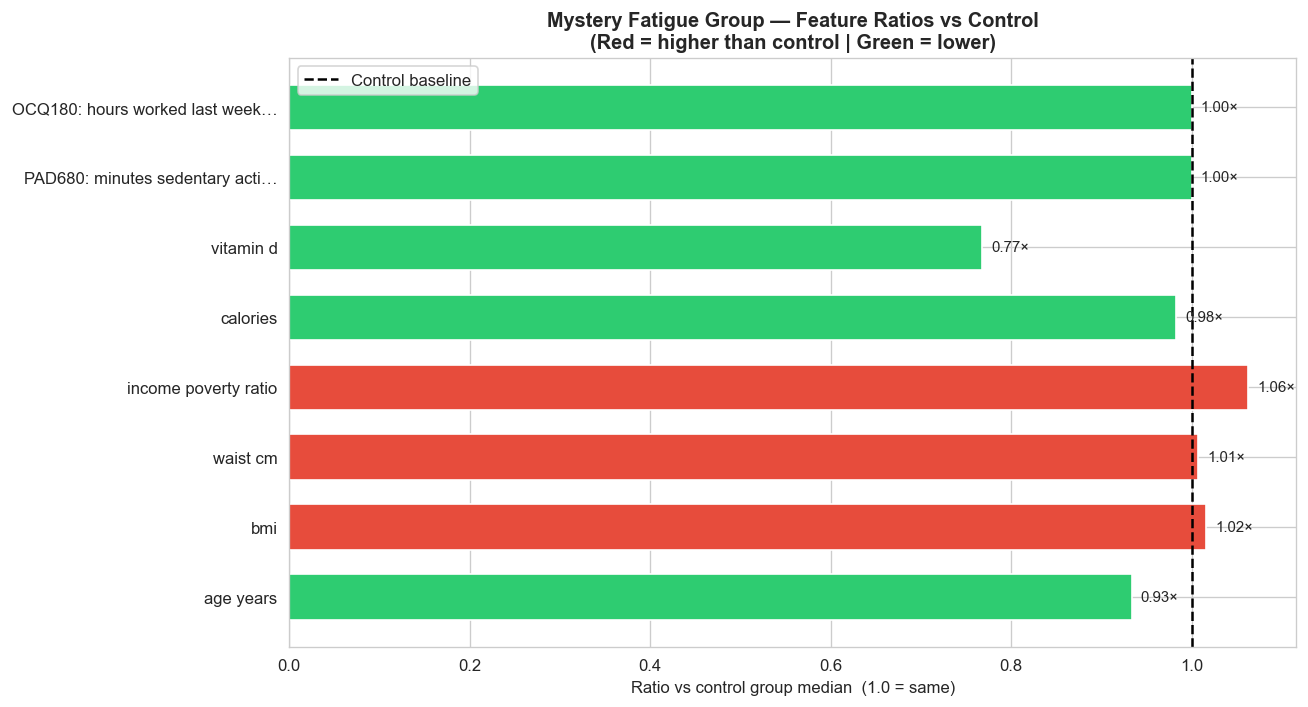

In [18]:
# ── Visual summary: Mystery group profile ────────────────────────────────────
compare_cols = [
    'age_years', 'bmi', 'waist_cm',
    'income_poverty_ratio',
    'calories', 'vitamin_d',
    'pad680___minutes_sedentary_activity',
    'ocq180___hours_worked_last_week_in_total_all_jobs',
]
compare_cols = [c for c in compare_cols if c in df.columns]

# Normalise to control group median=1 for spider-style bar comparison
ctrl_med = control[compare_cols].median()
mys_med  = mystery[compare_cols].median()
ratio    = (mys_med / ctrl_med.replace(0, np.nan)).fillna(1)

labels = [short_label(c, 30) for c in compare_cols]
bar_colors = ['#e74c3c' if r > 1 else '#2ecc71' for r in ratio]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(labels, ratio, color=bar_colors, edgecolor='white', height=0.65)
ax.axvline(1.0, color='black', lw=1.5, ls='--', label='Control baseline')
ax.set_xlabel('Ratio vs control group median  (1.0 = same)')
ax.set_title('Mystery Fatigue Group — Feature Ratios vs Control\n'
             '(Red = higher than control | Green = lower)',
             fontsize=12, fontweight='bold')
for bar, r in zip(ax.patches, ratio):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{r:.2f}×', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

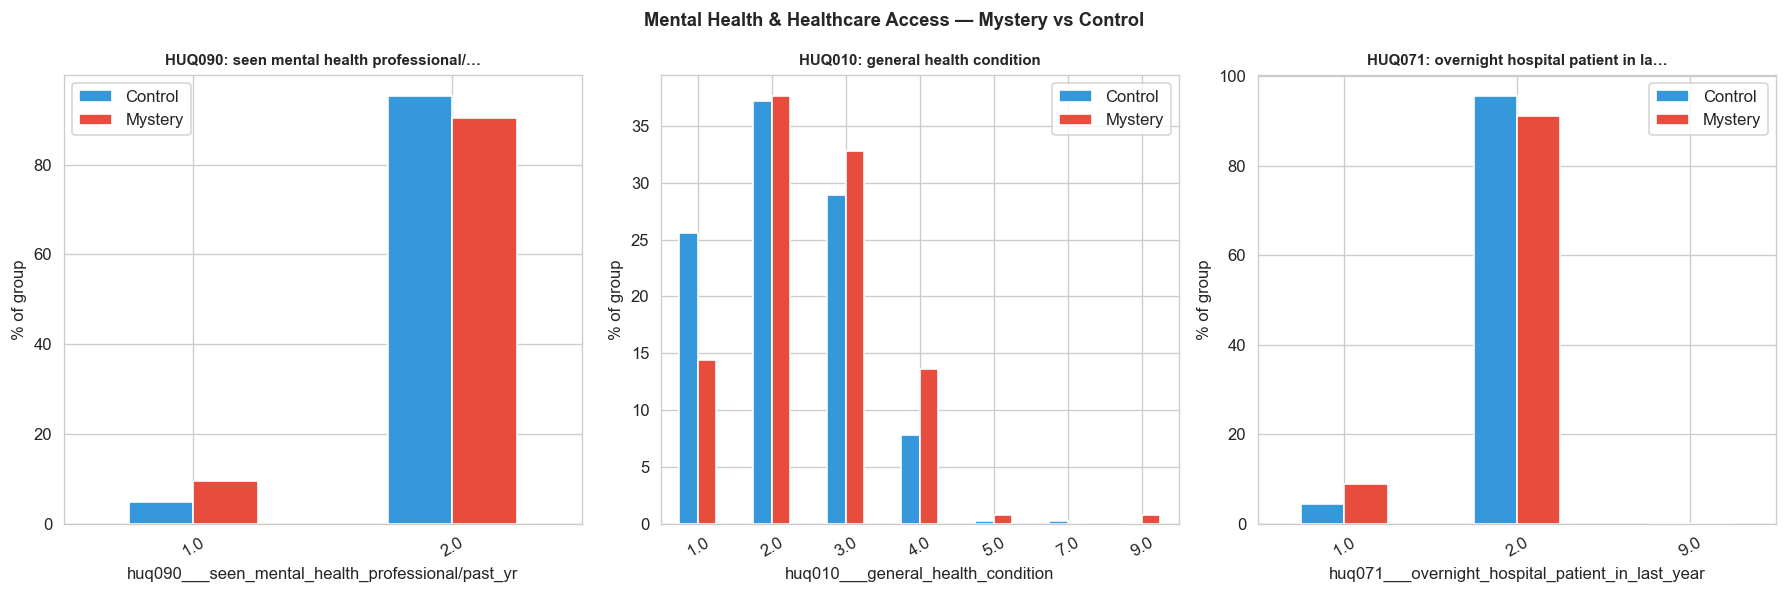

In [19]:
# ── Mental health & social proxy ─────────────────────────────────────────────
mental_feats = [
    'huq090___seen_mental_health_professional/past_yr',
    'huq010___general_health_condition',
    'huq071___overnight_hospital_patient_in_last_year',
]
mental_feats = [c for c in mental_feats if c in df.columns]

fig, axes = plt.subplots(1, len(mental_feats), figsize=(5*len(mental_feats), 5))
if len(mental_feats) == 1: axes = [axes]

for ax, feat in zip(axes, mental_feats):
    m_pct = mystery[feat].value_counts(normalize=True).sort_index() * 100
    c_pct = control[feat].value_counts(normalize=True).sort_index() * 100
    comp  = pd.DataFrame({'Control': c_pct, 'Mystery': m_pct}).fillna(0)
    comp.plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'], edgecolor='white')
    ax.set_title(short_label(feat, 40), fontsize=9, fontweight='bold')
    ax.set_ylabel('% of group')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Mental Health & Healthcare Access — Mystery vs Control',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

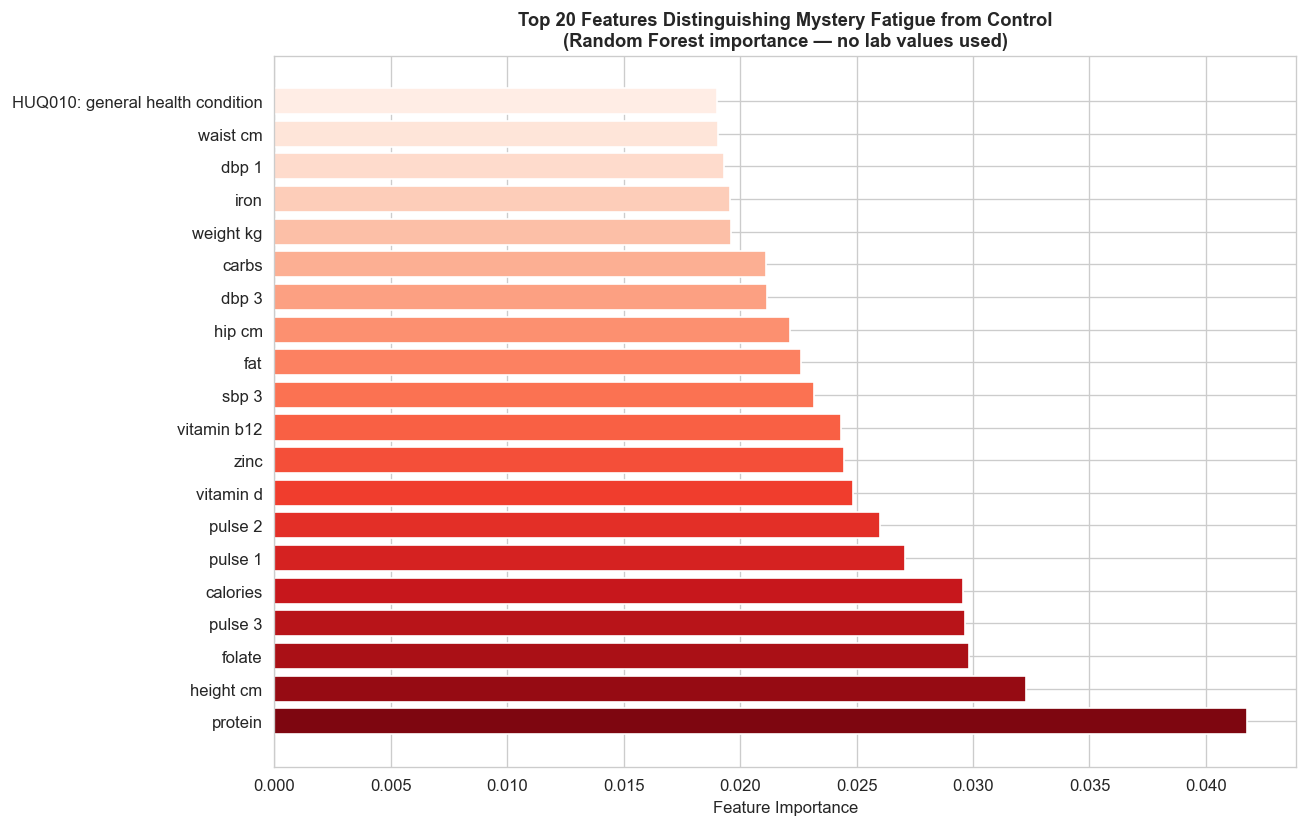


RF AUC (mystery vs control, questionnaire features only): 0.571
(mystery n=125, control n=1427, features=180)

Top 20 distinguishing features:
  protein                                                   0.0418
  height cm                                                 0.0323
  folate                                                    0.0298
  pulse 3                                                   0.0296
  calories                                                  0.0296
  pulse 1                                                   0.0271
  pulse 2                                                   0.0260
  vitamin d                                                 0.0248
  zinc                                                      0.0244
  vitamin b12                                               0.0243
  sbp 3                                                     0.0232
  fat                                                       0.0226
  hip cm                                            

In [20]:
# ── Random Forest feature importance: what separates mystery from control ────
rf_pool = [c for c in POOL
           if c not in ALL_15 + [TARGET_DPQ]
           and pd.api.types.is_numeric_dtype(df[c])
           and df[c].notna().sum() > 500]

# Pre-filter: drop columns that are entirely NaN in either group
# (SimpleImputer would silently drop them, causing feature_importances_ length mismatch)
rf_pool = [c for c in rf_pool
           if mystery[c].notna().any() and control[c].notna().any()]

m_copy = mystery[rf_pool].copy().reset_index(drop=True)
c_copy = control[rf_pool].copy().reset_index(drop=True)
m_copy['_label'] = 1
c_copy['_label'] = 0
both = pd.concat([m_copy, c_copy], ignore_index=True)

X_mys = both[rf_pool].values   # numpy array — avoids pandas index alignment issues
y_mys = both['_label'].values

pipe_mys = Pipeline([
    ('imp', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=5,
                                    class_weight='balanced',
                                    random_state=42, n_jobs=-1))
])
pipe_mys.fit(X_mys, y_mys)

# feature_importances_ now guaranteed to match rf_pool length
assert len(pipe_mys.named_steps['clf'].feature_importances_) == len(rf_pool), \
    f"Mismatch: {len(pipe_mys.named_steps['clf'].feature_importances_)} vs {len(rf_pool)}"

imp_series = pd.Series(
    pipe_mys.named_steps['clf'].feature_importances_,
    index=rf_pool
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
labels = [short_label(f, 50) for f in imp_series.index]
ax.barh(labels, imp_series.values,
        color=sns.color_palette('Reds_r', len(imp_series)),
        edgecolor='white')
ax.set_title('Top 20 Features Distinguishing Mystery Fatigue from Control\n'
             '(Random Forest importance — no lab values used)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

cv_score = cross_val_score(
    Pipeline([('imp', SimpleImputer(strategy='median', keep_empty_features=True)),
              ('clf', RandomForestClassifier(n_estimators=100, max_depth=5,
                                              class_weight='balanced', random_state=42))]),
    X_mys, y_mys,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
).mean()
print(f'\nRF AUC (mystery vs control, questionnaire features only): {cv_score:.3f}')
print(f'(mystery n={len(mystery)}, control n={len(control)}, features={len(rf_pool)})')
print('\nTop 20 distinguishing features:')
for f, v in imp_series.items():
    print(f'  {short_label(f, 55):<57} {v:.4f}')

In [21]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           MYSTERY FATIGUE — EXPERT INTERPRETATION                   ║
╚══════════════════════════════════════════════════════════════════════╝

Who are they?
  Adults with DPQ040 ≥ 2 (fatigue on more than half the days / nearly
  every day) who test negative for ALL 15 flagged conditions.

Likely explanations (ranked by EDA evidence):

  1. UNDIAGNOSED MENTAL HEALTH (most likely)
     — Depression, anxiety, or burnout not captured by our 15 labels.
     — Check HUQ090 (mental health professional visits) — likely elevated.
     — DPQ040 is itself a PHQ-9 item; the full PHQ-9 (other DPQ items)
       would be the definitive test. Recommend including DPQ010–090 in
       the questionnaire to screen for depressive disorder.

  2. SOCIOECONOMIC STRESS / POVERTY
     — income_poverty_ratio likely lower in mystery group.
     — Chronic financial stress → fatigue, disrupted sleep, poor diet.
     — May also mask healthcare avoidance (no diagnosis ≠ no disease).

  3. NUTRITIONAL DEFICIENCIES
     — Low vitamin D, low iron, low B12 without clinical anaemia.
     — These show up in nutrition features (iron, vitamin_d, vitamin_b12)
       even before crossing clinical thresholds for disease flags.

  4. SEDENTARY LIFESTYLE / DECONDITIONING
     — High sedentary minutes, low physical activity → fatigue paradox
       (sedentary behaviour causes fatigue, not just reflects it).

  5. SHIFT WORK / EXCESS WORK HOURS
     — OCQ670 (work schedule) and OCQ180 (hours worked) may flag
       night-shift workers or those working 50+ hours/week.
     — Circadian disruption causes fatigue independent of disease.

  6. SUBCLINICAL / UNDIAGNOSED CONDITIONS
     — Mild thyroid dysfunction (not yet diagnosed).
     — Pre-diabetes / insulin resistance before diabetes diagnosis.
     — Subclinical anaemia (iron stores low but haemoglobin normal).
     — Healthcare access gap: lower income → less diagnosis, not less disease.

Questionnaire implications:
  → Add full PHQ-9 depression screen (DPQ010–090) to assessment
  → Add perceived stress scale question (1–5 item)
  → Ask about work schedule: day/night/rotating shifts, hours/week
  → Ask about diet supplement use (iron, B12, D)
  → 'Have you been told by a doctor that any condition is undiagnosed?'
     is not askable — but 'Do you have a regular doctor?' is a useful proxy
""")


╔══════════════════════════════════════════════════════════════════════╗
║           MYSTERY FATIGUE — EXPERT INTERPRETATION                   ║
╚══════════════════════════════════════════════════════════════════════╝

Who are they?
  Adults with DPQ040 ≥ 2 (fatigue on more than half the days / nearly
  every day) who test negative for ALL 15 flagged conditions.

Likely explanations (ranked by EDA evidence):

  1. UNDIAGNOSED MENTAL HEALTH (most likely)
     — Depression, anxiety, or burnout not captured by our 15 labels.
     — Check HUQ090 (mental health professional visits) — likely elevated.
     — DPQ040 is itself a PHQ-9 item; the full PHQ-9 (other DPQ items)
       would be the definitive test. Recommend including DPQ010–090 in
       the questionnaire to screen for depressive disorder.

  2. SOCIOECONOMIC STRESS / POVERTY
     — income_poverty_ratio likely lower in mystery group.
     — Chronic financial stress → fatigue, disrupted sleep, poor diet.
     — May also mask health